# **📖Smart Logistics ETA Prediction : Using Machine-Learning Algorithms**


# **🎯Objective**

**To develop a reliable machine learning model that accurately predicts delivery times by leveraging data cleaning, exploratory data analysis, feature engineering, cross-validation, and hyperparameter tuning, ultimately enabling smarter logistics planning and improved customer satisfaction.**

### 1. **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split,RandomizedSearchCV,KFold,cross_validate,learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
from scipy.stats import uniform,randint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping

### **2. Load The dataset**

In [2]:
df = pd.read_json('/content/sample_data/archive.zip')

In [3]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41948,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,08-03-2022,21:47:47,21:59:27,conditions Windy,Jam,2,Drinks,motorcycle,1.0,No,Metropolitian,(min) 33
41949,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:36:22,11:48:07,conditions Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,(min) 32
41950,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:56,0:08:55,conditions Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,(min) 16
41951,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:40:13,13:42:00,conditions Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,(min) 26


### **3. Understand the data**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [5]:
df.shape

(41953, 20)

### **4. Data Cleaning**

In [6]:
df.drop(columns=['ID','Delivery_person_ID'],axis=1,inplace=True)

In [7]:
df.isnull().sum()

,0
Delivery_person_Age,1719
Delivery_person_Ratings,1763
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1600
Time_Order_picked,0
Weatherconditions,0


In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0
Time_Order_picked,0
Weatherconditions,0


In [10]:
df.shape

(39263, 18)

In [11]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30


In [12]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries
count,39263.000000,39263.000000,39263.000000,39263.000000,39263.000000,39263.000000,39263.000000,39263.000000
mean,29.567150,4.633278,18.911097,76.917991,18.974853,76.981748,0.998981,0.744339
std,5.761008,0.315449,5.470168,3.498981,5.471993,3.499183,0.816673,0.572529
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065801,73.940547,0.000000,0.000000
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.663067,1.000000,1.000000
75%,35.000000,4.900000,22.751234,78.347554,22.820040,78.403391,2.000000,1.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39263 entries, 0 to 41952
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          39263 non-null  float64
 1   Delivery_person_Ratings      39263 non-null  float64
 2   Restaurant_latitude          39263 non-null  float64
 3   Restaurant_longitude         39263 non-null  float64
 4   Delivery_location_latitude   39263 non-null  float64
 5   Delivery_location_longitude  39263 non-null  float64
 6   Order_Date                   39263 non-null  object 
 7   Time_Orderd                  39263 non-null  object 
 8   Time_Order_picked            39263 non-null  object 
 9   Weatherconditions            39263 non-null  object 
 10  Road_traffic_density         39263 non-null  object 
 11  Vehicle_condition            39263 non-null  int64  
 12  Type_of_order                39263 non-null  object 
 13  Type_of_vehicle      

In [14]:
cat_cols = df.select_dtypes(include=np.object_).columns
columns = []
for i in cat_cols :
  columns.append(i)
print(columns)

['Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Time_taken(min)']


In [15]:
for col in columns :
  print(f"{col} Total Unique Values : {df[col].nunique()}")
  print(f"{col} Unique Values : {df[col].unique()}")
  print("\n")

Order_Date Total Unique Values : 44
Order_Date Unique Values : ['19-03-2022' '25-03-2022' '05-04-2022' '26-03-2022' '11-03-2022'
 '04-03-2022' '14-03-2022' '20-03-2022' '12-02-2022' '13-02-2022'
 '14-02-2022' '02-04-2022' '01-03-2022' '16-03-2022' '15-02-2022'
 '10-03-2022' '27-03-2022' '12-03-2022' '01-04-2022' '05-03-2022'
 '11-02-2022' '08-03-2022' '03-04-2022' '30-03-2022' '28-03-2022'
 '18-03-2022' '04-04-2022' '24-03-2022' '09-03-2022' '29-03-2022'
 '31-03-2022' '17-03-2022' '15-03-2022' '18-02-2022' '23-03-2022'
 '16-02-2022' '13-03-2022' '02-03-2022' '07-03-2022' '03-03-2022'
 '06-03-2022' '21-03-2022' '06-04-2022' '17-02-2022']


Time_Orderd Total Unique Values : 25123
Time_Orderd Unique Values : ['11:33:33' '19:45:37' '8:32:58' ... '21:47:47' '23:50:56' '17:12:55']


Time_Order_picked Total Unique Values : 25846
Time_Order_picked Unique Values : ['11:45:29' '19:51:49' '8:48:47' ... '22:03:10' '11:48:07' '13:42:00']


Weatherconditions Total Unique Values : 6
Weatherconditions

In [16]:
def clean_data(data):
    data['Weatherconditions'] = (data['Weatherconditions'].str.strip().str.replace('conditions', '', regex=False).str.strip())
    data['Road_traffic_density'] = data['Road_traffic_density'].str.strip()
    data['Type_of_order'] = data['Type_of_order'].str.strip()
    data['Type_of_vehicle'] = data['Type_of_vehicle'].str.strip()
    data['Festival'] = data['Festival'].str.strip().replace({'NaN': 'Unknown'})
    data['City'] = data['City'].str.strip().replace({'NaN': 'Unknown'})
    data['Time_taken(min)'] = (data['Time_taken(min)'].str.replace('(min) ', '', regex=False).str.strip())
    data['Time_taken(min)'] = data['Time_taken(min)'].astype(float)

    return data

df = clean_data(df)

In [17]:
df

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41948,35.0,4.2,23.371292,85.327872,23.481292,85.437872,08-03-2022,21:47:47,21:59:27,Windy,Jam,2,Drinks,motorcycle,1.0,No,Metropolitian,33.0
41949,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:36:22,11:48:07,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32.0
41950,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:56,0:08:55,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16.0
41951,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:40:13,13:42:00,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26.0


In [18]:
for col in columns :
  print(f"{col} Total Unique Values : {df[col].nunique()}")
  print(f"{col} Unique Values : {df[col].unique()}")
  print("\n")

Order_Date Total Unique Values : 44
Order_Date Unique Values : ['19-03-2022' '25-03-2022' '05-04-2022' '26-03-2022' '11-03-2022'
 '04-03-2022' '14-03-2022' '20-03-2022' '12-02-2022' '13-02-2022'
 '14-02-2022' '02-04-2022' '01-03-2022' '16-03-2022' '15-02-2022'
 '10-03-2022' '27-03-2022' '12-03-2022' '01-04-2022' '05-03-2022'
 '11-02-2022' '08-03-2022' '03-04-2022' '30-03-2022' '28-03-2022'
 '18-03-2022' '04-04-2022' '24-03-2022' '09-03-2022' '29-03-2022'
 '31-03-2022' '17-03-2022' '15-03-2022' '18-02-2022' '23-03-2022'
 '16-02-2022' '13-03-2022' '02-03-2022' '07-03-2022' '03-03-2022'
 '06-03-2022' '21-03-2022' '06-04-2022' '17-02-2022']


Time_Orderd Total Unique Values : 25123
Time_Orderd Unique Values : ['11:33:33' '19:45:37' '8:32:58' ... '21:47:47' '23:50:56' '17:12:55']


Time_Order_picked Total Unique Values : 25846
Time_Order_picked Unique Values : ['11:45:29' '19:51:49' '8:48:47' ... '22:03:10' '11:48:07' '13:42:00']


Weatherconditions Total Unique Values : 6
Weatherconditions

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39263 entries, 0 to 41952
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          39263 non-null  float64
 1   Delivery_person_Ratings      39263 non-null  float64
 2   Restaurant_latitude          39263 non-null  float64
 3   Restaurant_longitude         39263 non-null  float64
 4   Delivery_location_latitude   39263 non-null  float64
 5   Delivery_location_longitude  39263 non-null  float64
 6   Order_Date                   39263 non-null  object 
 7   Time_Orderd                  39263 non-null  object 
 8   Time_Order_picked            39263 non-null  object 
 9   Weatherconditions            39263 non-null  object 
 10  Road_traffic_density         39263 non-null  object 
 11  Vehicle_condition            39263 non-null  int64  
 12  Type_of_order                39263 non-null  object 
 13  Type_of_vehicle      

In [20]:
df['Festival'].value_counts()

,count
Festival,
No,38291
Yes,777
Unknown,195


In [21]:
df['City'].value_counts()

,count
City,
Metropolitian,29423
Urban,8682
Unknown,1020
Semi-Urban,138


In [22]:
df = df[df['Festival'].isin(['Yes', 'No'])]

In [23]:
df.shape

(39068, 18)

In [24]:
df['Festival'].value_counts()

,count
Festival,
No,38291
Yes,777


### **5. Feature Engineering**

In [25]:
def calculate_haversine(df):
    # Convert degrees to radians
    lat1, lon1 = np.radians(df['Restaurant_latitude']), np.radians(df['Restaurant_longitude'])
    lat2, lon2 = np.radians(df['Delivery_location_latitude']), np.radians(df['Delivery_location_longitude'])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Earth's radius in kilometers is 6371
    df['distance_km'] = 6371 * c
    return df

df = calculate_haversine(df)

/tmp/ipykernel_892/1933861913.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance_km'] = 6371 * c


In [26]:
def assign_rating_tier(rating):
        if rating >= 4.8: return 'Top_Tier'
        elif rating >= 4.5: return 'High_Tier'
        elif rating < 4.0: return 'Critical'
        else: return 'Average'

df['driver_tier'] = df['Delivery_person_Ratings'].apply(assign_rating_tier)

df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
df['day_of_week'] = df['Order_Date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

/tmp/ipykernel_892/3155221915.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['driver_tier'] = df['Delivery_person_Ratings'].apply(assign_rating_tier)
/tmp/ipykernel_892/3155221915.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
/tmp/ipykernel_892/3155221915.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [27]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,...,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km,driver_tier,day_of_week,is_weekend
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:33:33,11:45:29,Sunny,...,Snack,motorcycle,0.0,No,Urban,24.0,3.025149,Top_Tier,5,1
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:37,19:51:49,Stormy,...,Snack,scooter,1.0,No,Metropolitian,33.0,20.183530,High_Tier,4,0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,8:32:58,8:48:47,Sandstorms,...,Drinks,motorcycle,1.0,No,Urban,26.0,1.552758,Average,5,1
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:03:58,18:12:52,Sunny,...,Buffet,motorcycle,1.0,No,Metropolitian,21.0,7.790401,High_Tier,1,0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:34:16,13:45:36,Cloudy,...,Snack,scooter,1.0,No,Metropolitian,30.0,6.210138,High_Tier,5,1


In [28]:
# Parse with seconds
t_ord = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
t_pick = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')

# Difference in minutes
df['Preparation_Time'] = (t_pick - t_ord).dt.total_seconds() / 60

# Midnight rollover (e.g. ordered 23:55:00, picked 00:10:00)
df.loc[df['Preparation_Time'] < 0, 'Preparation_Time'] += 24 * 60

df['Preparation_Time'] = np.where(df['Preparation_Time'] > 1400, (24 * 60) - df['Preparation_Time'], df['Preparation_Time'])

/tmp/ipykernel_892/1603258566.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Preparation_Time'] = (t_pick - t_ord).dt.total_seconds() / 60
/tmp/ipykernel_892/1603258566.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Preparation_Time'] = np.where(df['Preparation_Time'] > 1400, (24 * 60) - df['Preparation_Time'], df['Preparation_Time'])


In [29]:
df['Time_Ordered_clean'] = df['Time_Orderd'].astype(str).str.strip()
df['Order_hour'] = df['Time_Ordered_clean'].str.split(':').str[0]
df['Order_hour'] = pd.to_numeric(df['Order_hour'], errors='coerce')

# Create Indian Meal Period based on order hour
def assign_meal(hour):
  if 7 <= hour <= 11: return 'Breakfast'
  elif 12 <= hour < 16: return 'Lunch'
  elif 16 <= hour < 19: return 'Evening_Snacks'
  elif 19 <= hour < 23: return 'Dinner'
  else: return 'Late_Night'

df['meal_period'] = df['Order_hour'].apply(assign_meal)

df['Age_Rating_ratio'] = (df['Delivery_person_Age'])/(df['Delivery_person_Ratings'] + 0.1)

/tmp/ipykernel_892/2279672162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_Ordered_clean'] = df['Time_Orderd'].astype(str).str.strip()
/tmp/ipykernel_892/2279672162.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_hour'] = df['Time_Ordered_clean'].str.split(':').str[0]
/tmp/ipykernel_892/2279672162.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

In [30]:
df

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,...,Time_taken(min),distance_km,driver_tier,day_of_week,is_weekend,Preparation_Time,Time_Ordered_clean,Order_hour,meal_period,Age_Rating_ratio
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:33:33,11:45:29,Sunny,...,24.0,3.025149,Top_Tier,5,1,11.933333,11:33:33,11,Breakfast,7.400000
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:37,19:51:49,Stormy,...,33.0,20.183530,High_Tier,4,0,6.200000,19:45:37,19,Dinner,7.391304
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,8:32:58,8:48:47,Sandstorms,...,26.0,1.552758,Average,5,1,15.816667,8:32:58,8,Breakfast,5.111111
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:03:58,18:12:52,Sunny,...,21.0,7.790401,High_Tier,1,0,8.900000,18:03:58,18,Evening_Snacks,7.916667
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:34:16,13:45:36,Cloudy,...,30.0,6.210138,High_Tier,5,1,11.333333,13:34:16,13,Lunch,6.808511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41948,35.0,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,21:47:47,21:59:27,Windy,...,33.0,16.600272,Average,1,0,11.666667,21:47:47,21,Dinner,8.139535
41949,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:36:22,11:48:07,Windy,...,32.0,1.489846,Top_Tier,3,0,11.750000,11:36:22,11,Breakfast,6.122449
41950,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:56,0:08:55,Cloudy,...,16.0,4.657195,Top_Tier,4,0,17.983333,23:50:56,23,Late_Night,6.000000
41951,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:40:13,13:42:00,Cloudy,...,26.0,6.232393,High_Tier,0,0,1.783333,13:40:13,13,Lunch,4.166667


In [31]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'distance_km', 'driver_tier', 'day_of_week', 'is_weekend',
       'Preparation_Time', 'Time_Ordered_clean', 'Order_hour', 'meal_period',
       'Age_Rating_ratio'],
      dtype='object')

### **6. Exploratory Data Analysis**

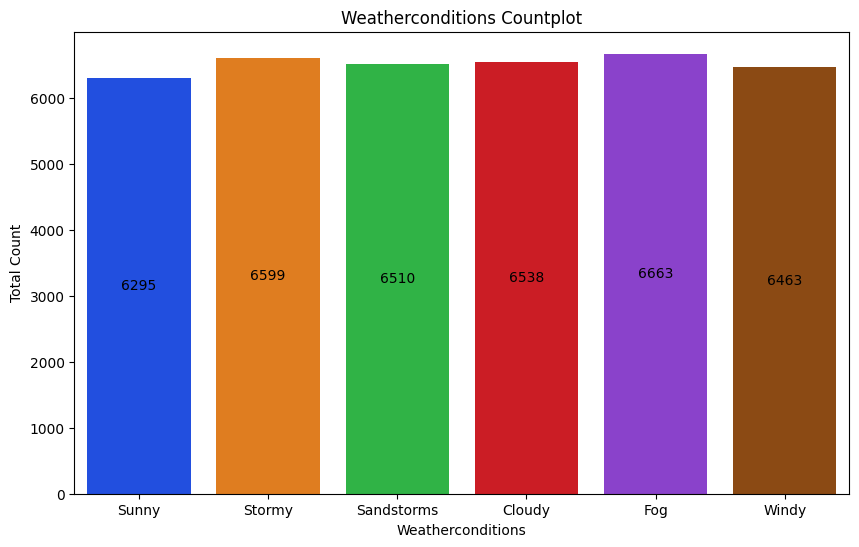

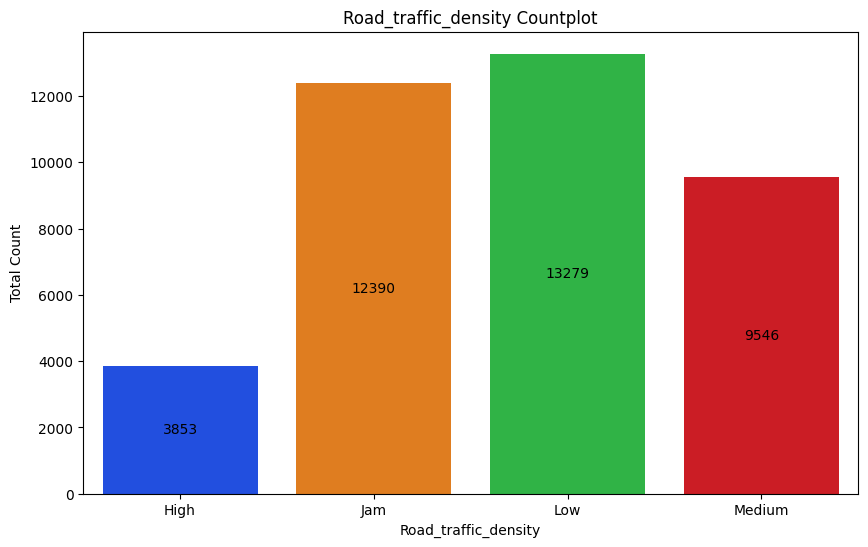

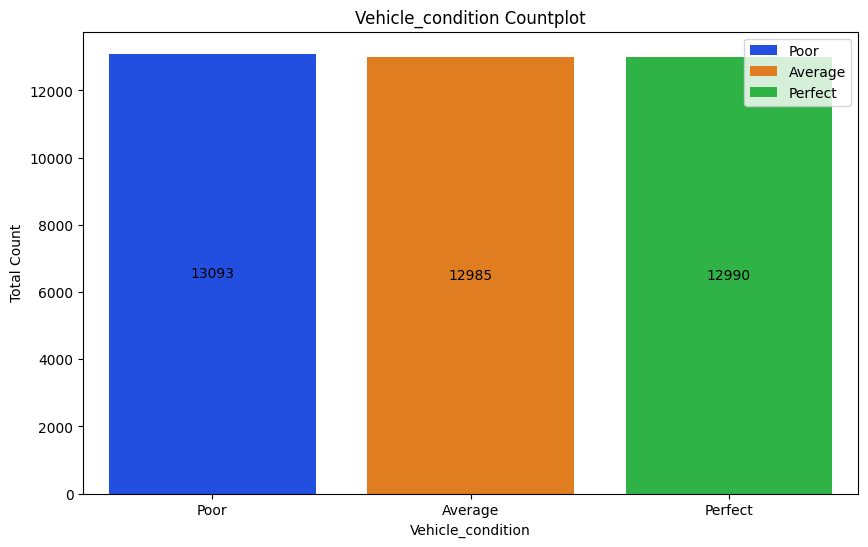

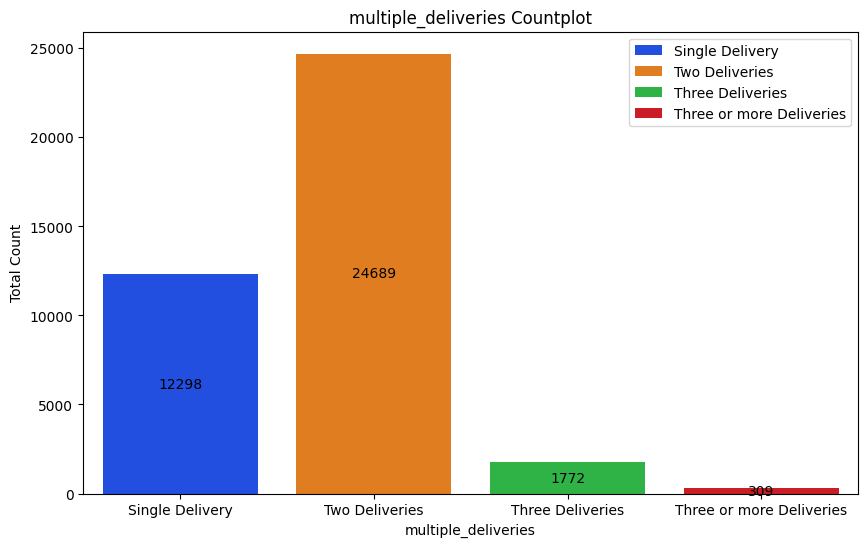

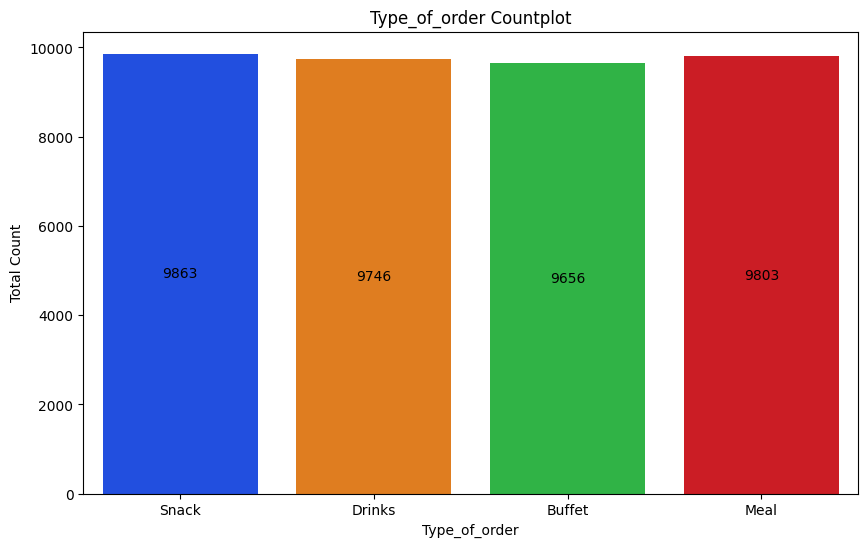

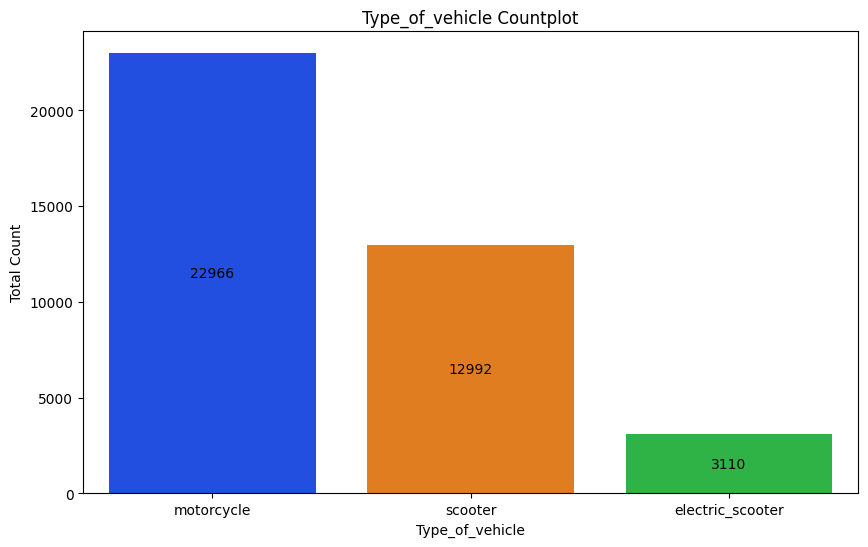

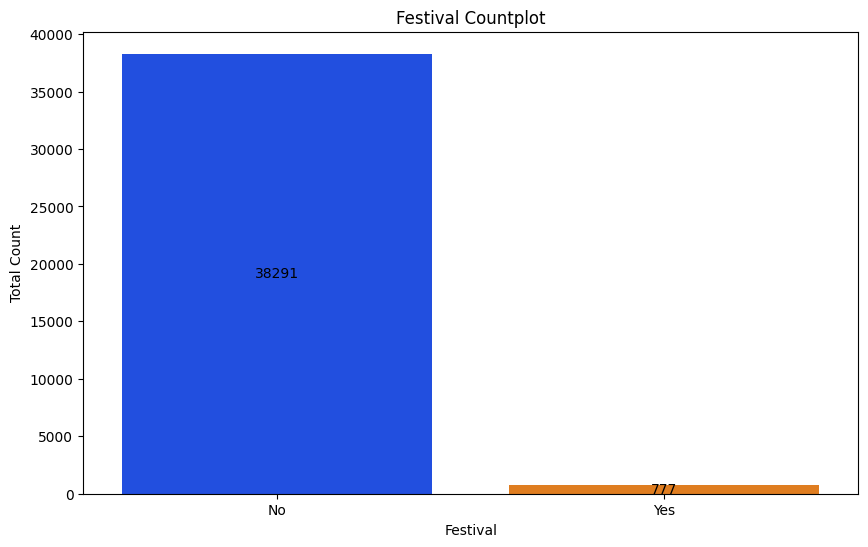

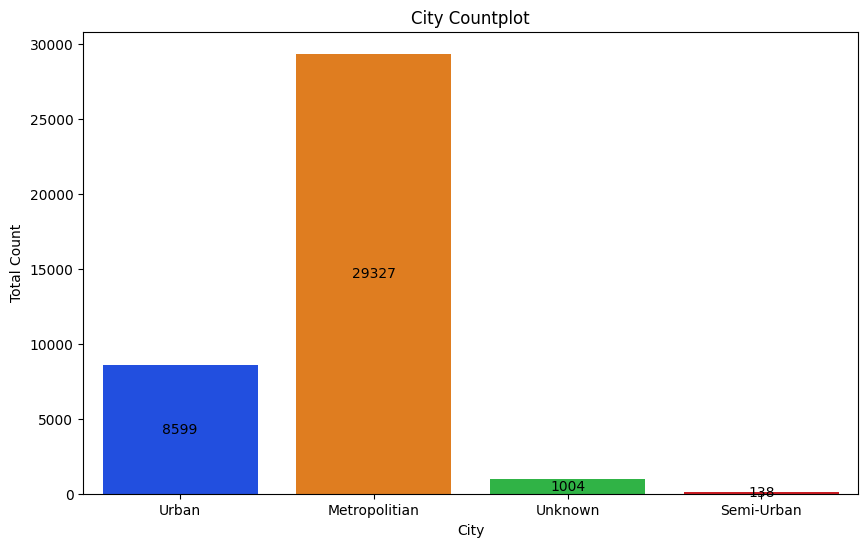

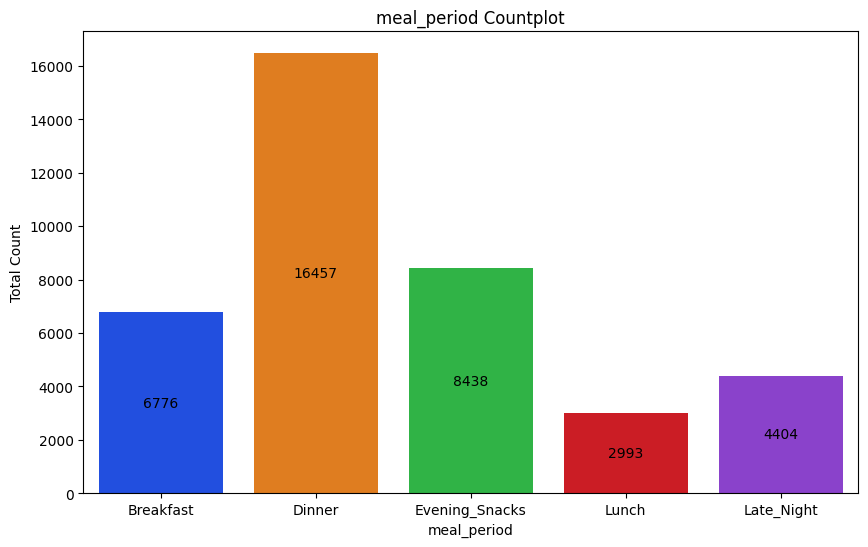

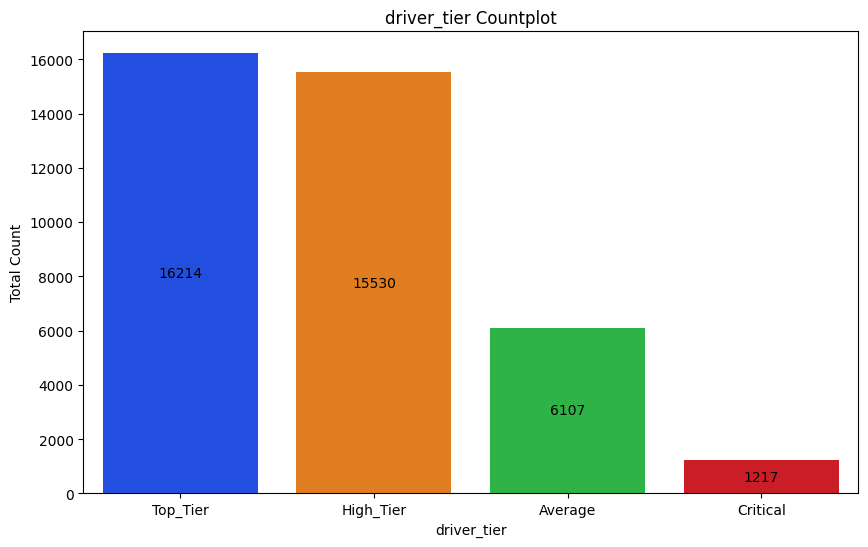

In [32]:
plt.style.use('default')
cols = ['Weatherconditions','Road_traffic_density','Vehicle_condition','multiple_deliveries','Type_of_order','Type_of_vehicle','Festival','City','meal_period','driver_tier']
conditions = ['Poor','Average','Perfect']
multiple_del = ['Single Delivery','Two Deliveries','Three Deliveries','Three or more Deliveries']

for col in cols :
  plt.figure(figsize=(10,6))
  plot = sns.countplot(x=df[col],palette='bright',hue=df[col])

  for i in plot.containers :
    plot.bar_label(i,label_type='center')

  plt.title(f"{col} Countplot")

  if col in ('Vehicle_condition') :
    plt.xticks(range(3),conditions)
    plot.legend(labels=conditions)

  elif col in ('multiple_deliveries') :
    plt.xticks(range(4),multiple_del)
    plot.legend(labels=multiple_del)

  plt.xlabel(f'{col}')
  plt.ylabel('Total Count')
  plt.show()

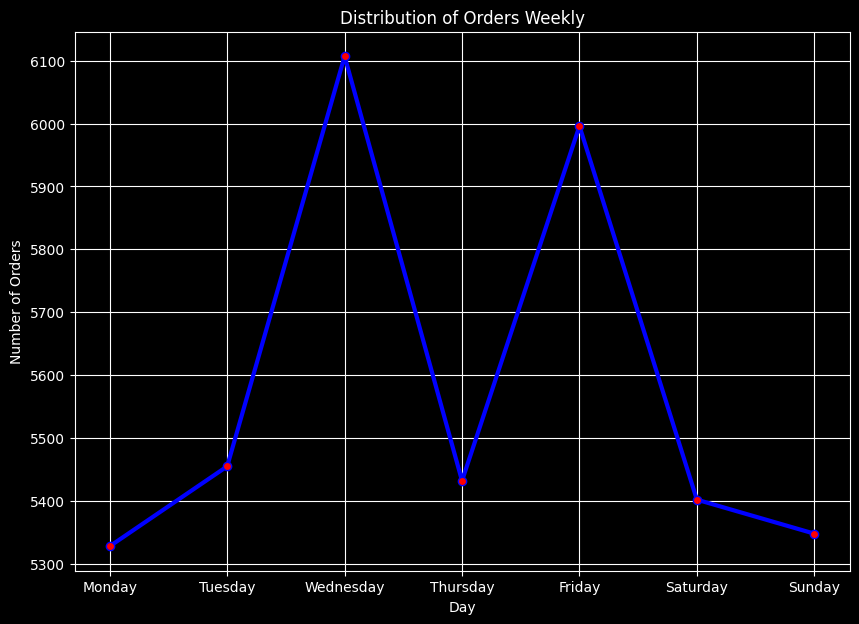

In [ ]:
plt.style.use('dark_background')
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,7))
plt.plot(df['day_of_week'].value_counts().sort_index(),marker='o',markerfacecolor='red',color='b',linewidth=3,alpha=1)
plt.xticks(range(7),day_names)
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.title('Distribution of Orders Weekly')
plt.grid()
plt.show()

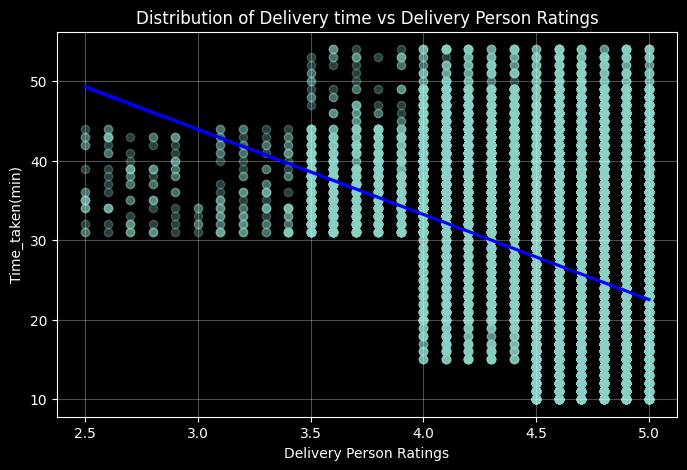

In [ ]:
plt.style.use('dark_background')

plt.figure(figsize=(8,5))
sns.regplot(data=df,x='Delivery_person_Ratings',y='Time_taken(min)',scatter_kws={'alpha':0.3},line_kws={'color':'blue'})
plt.xlabel('Delivery Person Ratings')
plt.ylabel('Time_taken(min)')
plt.title('Distribution of Delivery time vs Delivery Person Ratings')
plt.grid(True,alpha=0.3)
plt.show()

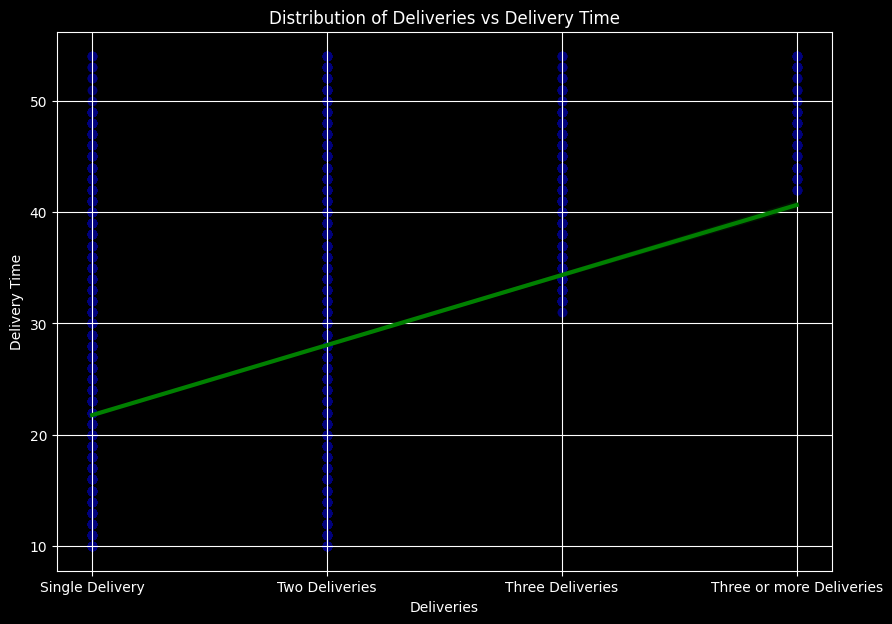

In [ ]:
plt.style.use('dark_background')
multiple_del = ['Single Delivery','Two Deliveries','Three Deliveries','Three or more Deliveries']

plt.figure(figsize=(10,7))
sns.regplot(data=df,x='multiple_deliveries',y='Time_taken(min)',scatter_kws={'color' : 'navy','alpha':0.3},line_kws={'color':'green','linewidth' : 3})
plt.xticks(range(4),multiple_del)
plt.xlabel('Deliveries')
plt.ylabel('Delivery Time')
plt.title('Distribution of Deliveries vs Delivery Time')
plt.grid()
plt.show()

<Figure size 800x500 with 0 Axes>

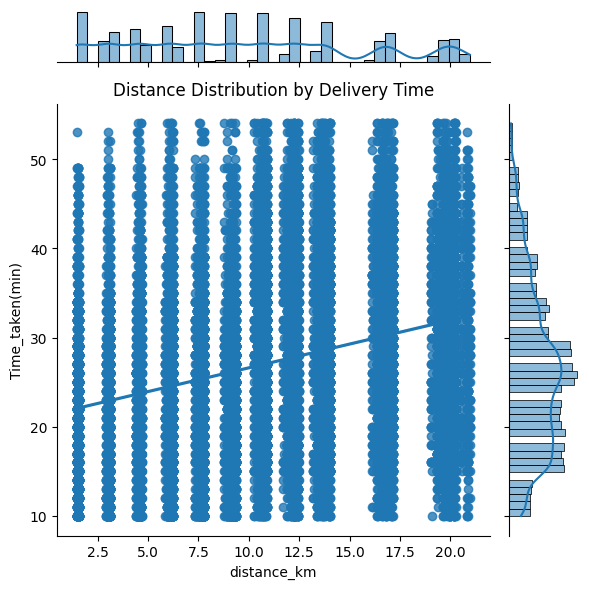

In [ ]:
plt.figure(figsize=(8,5))
sns.jointplot(data=df,x='distance_km',y='Time_taken(min)',kind='reg')
plt.title('Distance Distribution by Delivery Time')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

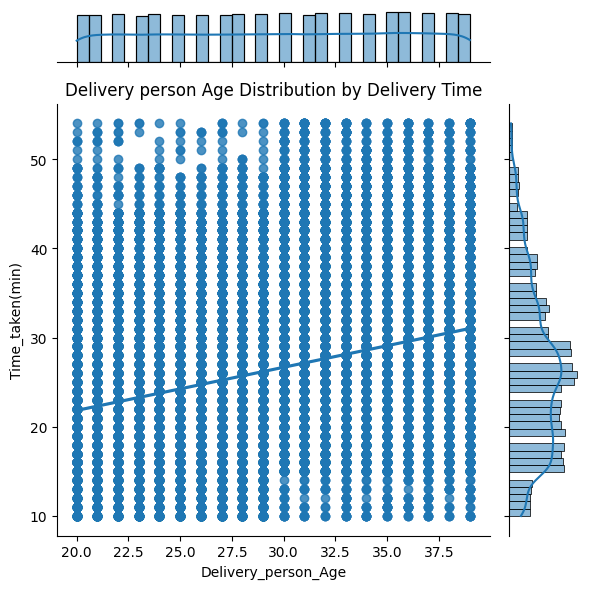

In [ ]:
plt.figure(figsize=(8,5))
sns.jointplot(data=df,x='Delivery_person_Age',y='Time_taken(min)',kind='reg')
plt.title('Delivery person Age Distribution by Delivery Time')
plt.tight_layout()
plt.show()

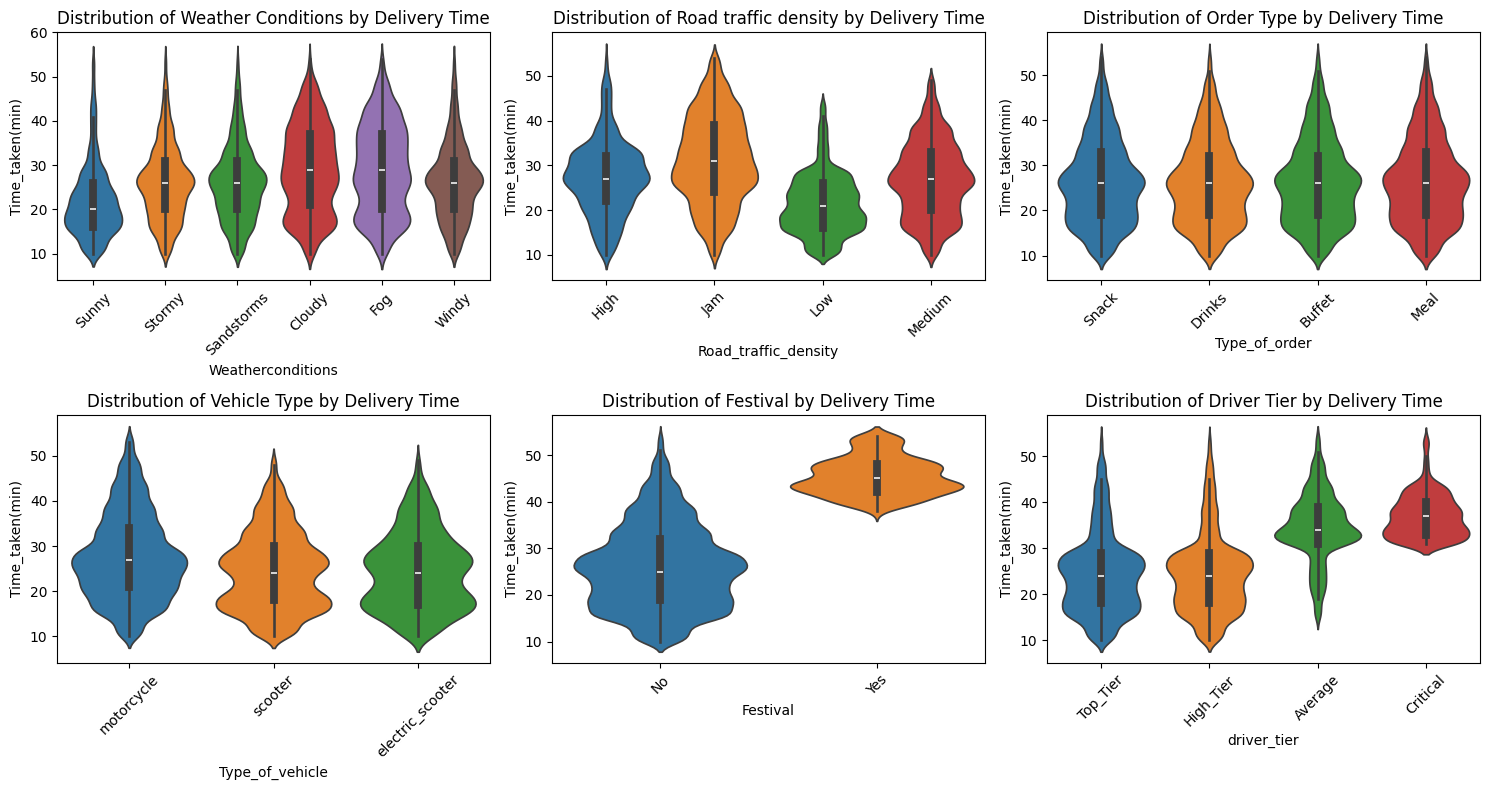

In [ ]:
plt.figure(figsize=(15,8))
plt.subplot(2,3,1)
sns.violinplot(x=df['Weatherconditions'],y=df['Time_taken(min)'],hue=df['Weatherconditions'],legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of Weather Conditions by Delivery Time')
plt.subplot(2,3,2)
sns.violinplot(x=df['Road_traffic_density'],y=df['Time_taken(min)'],hue=df['Road_traffic_density'],legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of Road traffic density by Delivery Time')
plt.subplot(2,3,3)
sns.violinplot(x=df['Type_of_order'],y=df['Time_taken(min)'],hue=df['Type_of_order'],legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of Order Type by Delivery Time')
plt.subplot(2,3,4)
sns.violinplot(x=df['Type_of_vehicle'],y=df['Time_taken(min)'],hue=df['Type_of_vehicle'],legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of Vehicle Type by Delivery Time')
plt.subplot(2,3,5)
sns.violinplot(x=df['Festival'],y=df['Time_taken(min)'],hue=df['Festival'],legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of Festival by Delivery Time')
plt.subplot(2,3,6)
sns.violinplot(x=df['driver_tier'],y=df['Time_taken(min)'],hue=df['driver_tier'],legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of Driver Tier by Delivery Time')
plt.tight_layout()
plt.show()

### **7. Data Preparation and further EDA**

In [ ]:
df['Road_traffic_density'] = df['Road_traffic_density'].map({'Low': 1, 'Medium': 2, 'High': 3, 'Jam': 4})
df['Weatherconditions'] = df['Weatherconditions'].map({'Sunny': 1, 'Cloudy': 2, 'Windy': 3, 'Sandstorms': 4, 'Stormy': 5, 'Fog': 5})
df['driver_tier'] = df['driver_tier'].map({'Top_Tier': 1, 'High_Tier': 2, 'Average': 3, 'Critical': 4})
df['Festival'] = df['Festival'].map({'Yes' : 1 , 'No' : 0})

/tmp/ipykernel_2664/3006617452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Road_traffic_density'] = df['Road_traffic_density'].map({'Low': 1, 'Medium': 2, 'High': 3, 'Jam': 4})
/tmp/ipykernel_2664/3006617452.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weatherconditions'] = df['Weatherconditions'].map({'Sunny': 1, 'Cloudy': 2, 'Windy': 3, 'Sandstorms': 4, 'Stormy': 5, 'Fog': 5})
/tmp/ipykernel_2664/3006617452.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [ ]:
df['Is_Peak_hour'] = df['Order_hour'].isin([12,13,14,19,20,21,22]).astype(int)
df['Weekend_Festival'] = df['is_weekend'] * df['Festival']

/tmp/ipykernel_2664/3546651811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Is_Peak_hour'] = df['Order_hour'].isin([12,13,14,19,20,21,22]).astype(int)
/tmp/ipykernel_2664/3546651811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weekend_Festival'] = df['is_weekend'] * df['Festival']


In [ ]:
df

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,...,driver_tier,day_of_week,is_weekend,Preparation_Time,Time_Ordered_clean,Order_hour,meal_period,Age_Rating_ratio,Is_Peak_hour,Weekend_Festival
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:33:33,11:45:29,1,...,1,5,1,11.933333,11:33:33,11,Breakfast,7.400000,0,0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:37,19:51:49,5,...,2,4,0,6.200000,19:45:37,19,Dinner,7.391304,1,0
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,8:32:58,8:48:47,4,...,3,5,1,15.816667,8:32:58,8,Breakfast,5.111111,0,0
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:03:58,18:12:52,1,...,2,1,0,8.900000,18:03:58,18,Evening_Snacks,7.916667,0,0
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:34:16,13:45:36,2,...,2,5,1,11.333333,13:34:16,13,Lunch,6.808511,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41948,35.0,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,21:47:47,21:59:27,3,...,3,1,0,11.666667,21:47:47,21,Dinner,8.139535,1,0
41949,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:36:22,11:48:07,3,...,1,3,0,11.750000,11:36:22,11,Breakfast,6.122449,0,0
41950,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:56,0:08:55,2,...,1,4,0,17.983333,23:50:56,23,Late_Night,6.000000,0,0
41951,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:40:13,13:42:00,2,...,2,0,0,1.783333,13:40:13,13,Lunch,4.166667,1,0


### **8. Feature Selection using Feature Importance**

In [ ]:
df.drop(columns=['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude','Order_Date','Time_Orderd','Time_Order_picked','Time_Ordered_clean','Type_of_order','is_weekend','day_of_week'],axis=1,inplace=True)

/tmp/ipykernel_2664/1360620577.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude','Order_Date','Time_Orderd','Time_Order_picked','Time_Ordered_clean','Type_of_order','is_weekend','day_of_week'],axis=1,inplace=True)


In [ ]:
df

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km,driver_tier,Preparation_Time,Order_hour,meal_period,Age_Rating_ratio,Is_Peak_hour,Weekend_Festival
0,37.0,4.9,1,3,2,motorcycle,0.0,0,Urban,24.0,3.025149,1,11.933333,11,Breakfast,7.400000,0,0
1,34.0,4.5,5,4,2,scooter,1.0,0,Metropolitian,33.0,20.183530,2,6.200000,19,Dinner,7.391304,1,0
2,23.0,4.4,4,1,0,motorcycle,1.0,0,Urban,26.0,1.552758,3,15.816667,8,Breakfast,5.111111,0,0
3,38.0,4.7,1,2,0,motorcycle,1.0,0,Metropolitian,21.0,7.790401,2,8.900000,18,Evening_Snacks,7.916667,0,0
4,32.0,4.6,2,3,1,scooter,1.0,0,Metropolitian,30.0,6.210138,2,11.333333,13,Lunch,6.808511,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41948,35.0,4.2,3,4,2,motorcycle,1.0,0,Metropolitian,33.0,16.600272,3,11.666667,21,Dinner,8.139535,1,0
41949,30.0,4.8,3,3,1,motorcycle,0.0,0,Metropolitian,32.0,1.489846,1,11.750000,11,Breakfast,6.122449,0,0
41950,30.0,4.9,2,1,1,scooter,0.0,0,Metropolitian,16.0,4.657195,1,17.983333,23,Late_Night,6.000000,0,0
41951,20.0,4.7,2,3,0,motorcycle,1.0,0,Metropolitian,26.0,6.232393,2,1.783333,13,Lunch,4.166667,1,0


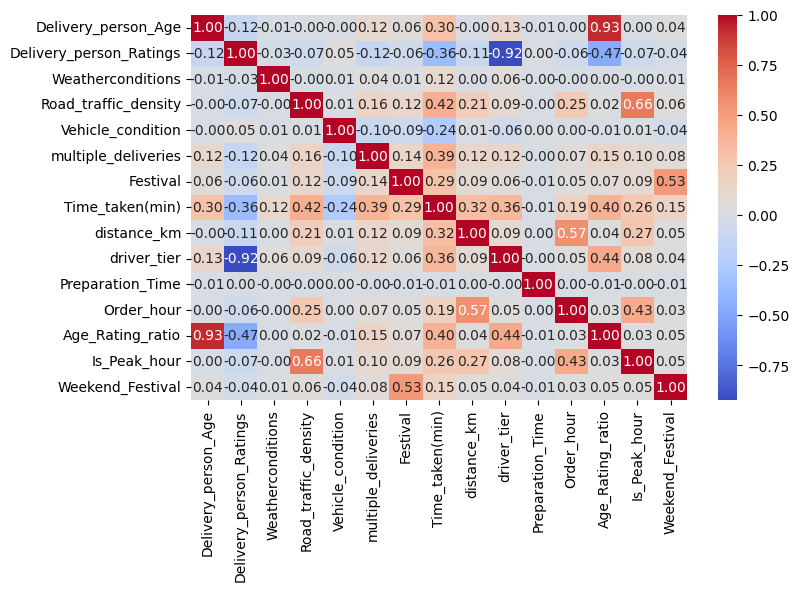

In [ ]:
plt.figure(figsize=(8,5))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

/tmp/ipykernel_522/251442126.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Delivery_person_Age'])
/tmp/ipykernel_522/251442126.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['distance_km'])
/tmp/ipykernel_522/251442126.py:9: UserWarning: 

`distplot` is a deprecated function an

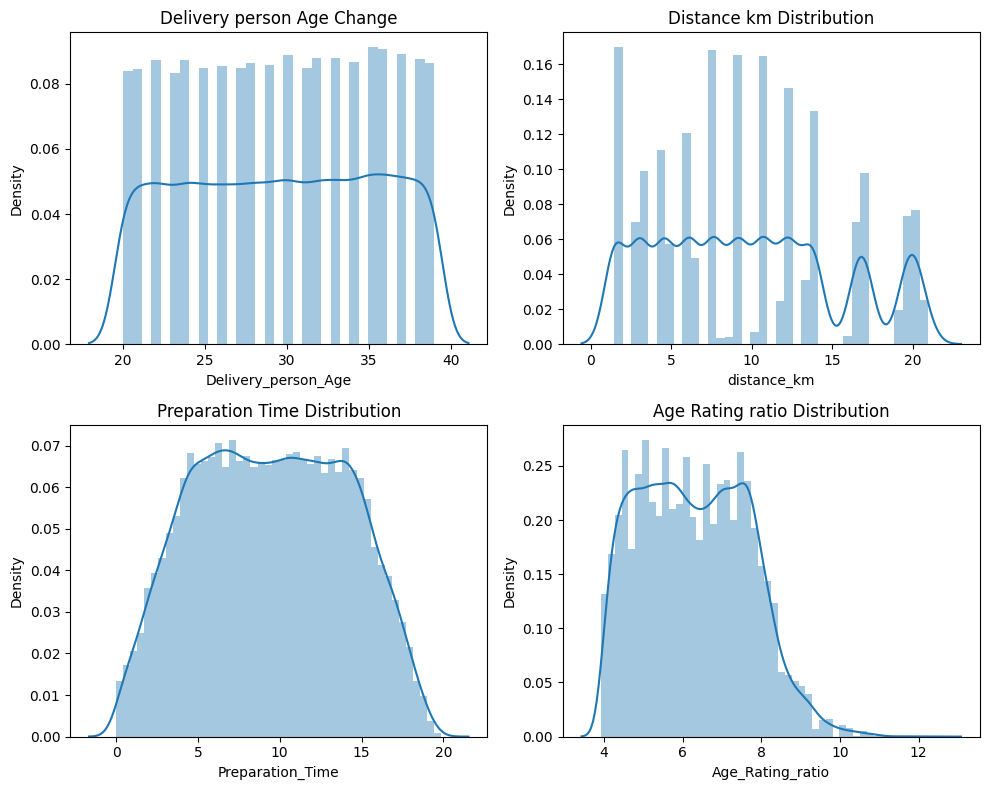

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.distplot(df['Delivery_person_Age'])
plt.title('Delivery person Age Change')
plt.subplot(2,2,2)
sns.distplot(df['distance_km'])
plt.title('Distance km Distribution')
plt.subplot(2,2,3)
sns.distplot(df['Preparation_Time'])
plt.title('Preparation Time Distribution')
plt.subplot(2,2,4)
sns.distplot(df['Age_Rating_ratio'])
plt.title('Age Rating ratio Distribution')
plt.tight_layout()
plt.show()

**8.2 Check for Outliers**

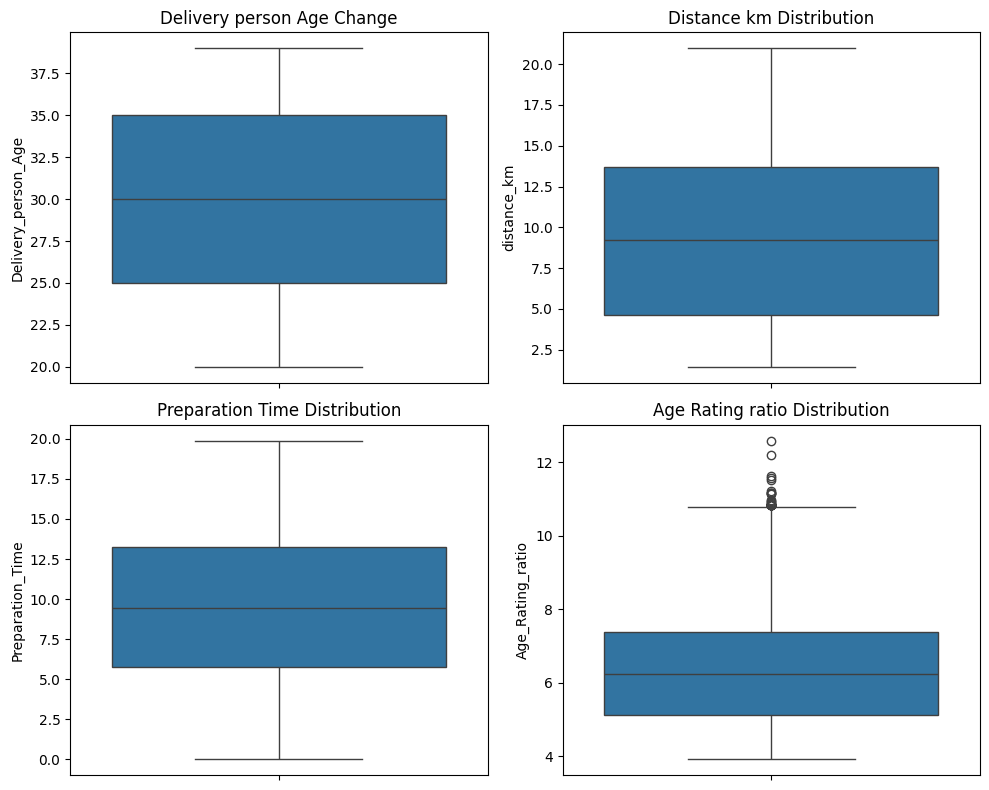

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.boxplot(df['Delivery_person_Age'])
plt.title('Delivery person Age Change')
plt.subplot(2,2,2)
sns.boxplot(df['distance_km'])
plt.title('Distance km Distribution')
plt.subplot(2,2,3)
sns.boxplot(df['Preparation_Time'])
plt.title('Preparation Time Distribution')
plt.subplot(2,2,4)
sns.boxplot(df['Age_Rating_ratio'])
plt.title('Age Rating ratio Distribution')
plt.tight_layout()
plt.show()

In [ ]:
for name in ['Delivery_person_Age','distance_km','Preparation_Time','Age_Rating_ratio'] :
  print(f"{name} : {df[name].skew()}")

Delivery_person_Age : -0.02336592309998592
distance_km : 0.31849924353242726
Preparation_Time : 0.009771198780067405
Age_Rating_ratio : 0.266770749619952


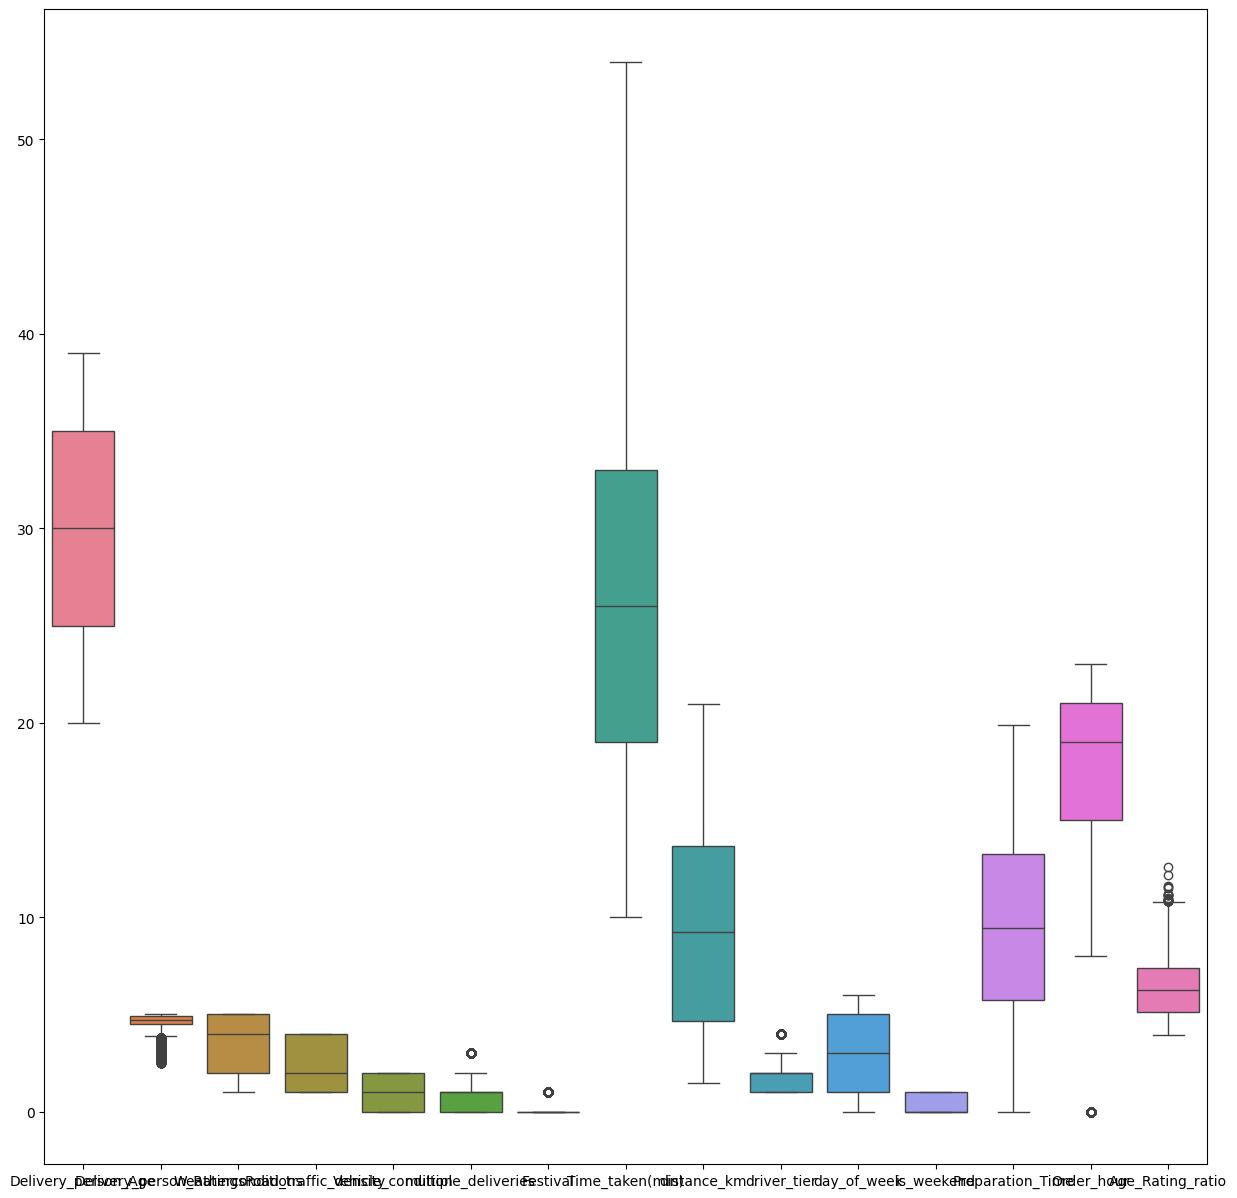

In [ ]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=df)
plt.show()

In [ ]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,Time_taken(min),distance_km,driver_tier,Preparation_Time,Order_hour,Age_Rating_ratio,Is_Peak_hour,Weekend_Festival
count,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000,39068.000000
mean,29.588973,4.632687,3.355943,2.393007,0.997364,0.746391,0.019888,26.467083,9.746338,1.803599,9.481075,17.418245,6.294718,0.478141,0.005580
std,5.760894,0.315943,1.486505,1.246058,0.817093,0.572249,0.139619,9.329925,5.598541,0.810792,4.566226,4.836058,1.371252,0.499528,0.074492
min,20.000000,2.500000,1.000000,1.000000,0.000000,0.000000,0.000000,10.000000,1.465067,1.000000,0.000000,0.000000,3.921569,0.000000,0.000000
25%,25.000000,4.500000,2.000000,1.000000,0.000000,0.000000,0.000000,19.000000,4.658000,1.000000,5.750000,15.000000,5.111111,0.000000,0.000000
50%,30.000000,4.700000,4.000000,2.000000,1.000000,1.000000,0.000000,26.000000,9.219692,2.000000,9.466667,19.000000,6.250000,0.000000,0.000000
75%,35.000000,4.900000,5.000000,4.000000,2.000000,1.000000,0.000000,33.000000,13.681057,2.000000,13.233333,21.000000,7.380952,1.000000,0.000000
max,39.000000,5.000000,5.000000,4.000000,2.000000,3.000000,1.000000,54.000000,20.969489,4.000000,19.883333,23.000000,12.580645,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39068 entries, 0 to 41952
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Delivery_person_Age      39068 non-null  float64
 1   Delivery_person_Ratings  39068 non-null  float64
 2   Weatherconditions        39068 non-null  int64  
 3   Road_traffic_density     39068 non-null  int64  
 4   Vehicle_condition        39068 non-null  int64  
 5   Type_of_vehicle          39068 non-null  object 
 6   multiple_deliveries      39068 non-null  float64
 7   Festival                 39068 non-null  int64  
 8   City                     39068 non-null  object 
 9   Time_taken(min)          39068 non-null  float64
 10  distance_km              39068 non-null  float64
 11  driver_tier              39068 non-null  int64  
 12  Preparation_Time         39068 non-null  float64
 13  Order_hour               39068 non-null  int64  
 14  meal_period              39

### **9. Splitting The dataset for Training and Testing**

In [ ]:
X = df.drop('Time_taken(min)',axis=1)
Y = df['Time_taken(min)']

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.1,random_state=42)

In [ ]:
X_train

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_vehicle,multiple_deliveries,Festival,City,distance_km,driver_tier,Preparation_Time,Order_hour,meal_period,Age_Rating_ratio,Is_Peak_hour,Weekend_Festival
3511,38.0,4.9,1,4,2,scooter,1.0,0,Metropolitian,16.384367,1,14.666667,21,Dinner,7.600000,1,0
11606,26.0,4.7,5,1,2,motorcycle,0.0,0,Urban,1.529825,2,8.550000,9,Breakfast,5.416667,0,0
36506,36.0,4.9,2,3,2,scooter,0.0,0,Urban,6.147161,1,2.933333,12,Lunch,7.200000,1,0
5620,36.0,5.0,2,1,2,scooter,0.0,0,Metropolitian,7.762606,1,3.133333,23,Late_Night,7.058824,0,0
8360,34.0,4.5,3,4,1,scooter,0.0,0,Metropolitian,13.184476,2,6.300000,20,Dinner,7.391304,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6729,39.0,4.8,5,2,2,scooter,1.0,0,Metropolitian,6.210608,1,13.100000,16,Evening_Snacks,7.959184,0,0
12094,35.0,4.2,5,3,0,motorcycle,1.0,0,Metropolitian,6.209442,3,6.550000,15,Lunch,8.139535,0,0
40980,31.0,4.5,5,4,2,motorcycle,1.0,0,Metropolitian,13.971217,2,1.316667,20,Dinner,6.739130,1,0
921,30.0,4.7,5,2,1,scooter,1.0,0,Metropolitian,7.790314,2,14.883333,18,Evening_Snacks,6.250000,0,0


In [ ]:
X_test

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_vehicle,multiple_deliveries,Festival,City,distance_km,driver_tier,Preparation_Time,Order_hour,meal_period,Age_Rating_ratio,Is_Peak_hour,Weekend_Festival
1919,24.0,4.4,3,4,0,motorcycle,1.0,0,Metropolitian,13.584306,3,10.750000,19,Dinner,5.333333,1,0
13944,32.0,4.6,5,1,2,scooter,1.0,0,Urban,20.253686,2,9.583333,22,Dinner,6.808511,1,0
19160,24.0,4.6,5,4,0,motorcycle,1.0,0,Metropolitian,4.587795,2,5.650000,21,Dinner,5.106383,1,0
27514,25.0,4.7,4,4,2,scooter,1.0,0,Urban,9.088084,2,7.200000,20,Dinner,5.208333,1,0
31655,35.0,4.8,5,2,1,motorcycle,1.0,0,Metropolitian,10.642019,1,7.083333,18,Evening_Snacks,7.142857,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27357,20.0,4.6,4,2,1,scooter,1.0,0,Urban,4.631614,2,13.800000,17,Evening_Snacks,4.255319,0,0
21231,25.0,4.8,3,4,1,scooter,1.0,0,Urban,10.587816,1,4.583333,20,Dinner,5.102041,1,0
31406,23.0,4.7,4,1,1,motorcycle,0.0,0,Metropolitian,3.040892,2,4.100000,8,Breakfast,4.791667,0,0
29675,35.0,4.5,3,2,0,motorcycle,1.0,0,Metropolitian,19.364488,2,2.133333,18,Evening_Snacks,7.608696,0,0


In [ ]:
Y_train

,Time_taken(min)
3511,22.0
11606,18.0
36506,27.0
5620,19.0
8360,39.0
...,...
6729,33.0
12094,32.0
40980,43.0
921,26.0


In [ ]:
Y_test

,Time_taken(min)
1919,31.0
13944,28.0
19160,24.0
27514,21.0
31655,35.0
...,...
27357,24.0
21231,22.0
31406,11.0
29675,30.0


In [ ]:
for i in X_train.columns :
  print(f"{i} Unique : {X_train[i].nunique()}")

Delivery_person_Age Unique : 20
Delivery_person_Ratings Unique : 26
Weatherconditions Unique : 5
Road_traffic_density Unique : 4
Vehicle_condition Unique : 3
Type_of_vehicle Unique : 3
multiple_deliveries Unique : 4
Festival Unique : 2
City Unique : 4
distance_km Unique : 4332
driver_tier Unique : 4
Preparation_Time Unique : 1615
Order_hour Unique : 17
meal_period Unique : 5
Age_Rating_ratio Unique : 370
Is_Peak_hour Unique : 2
Weekend_Festival Unique : 2


### **10. Data Preprocessing**

In [ ]:
cat_col = X_train.select_dtypes(include=np.object_).columns
cat_cols = []
for i in cat_col :
  cat_cols.append(i)
print(cat_cols)

['Type_of_vehicle', 'City', 'meal_period']


In [ ]:
num_cols = ['Delivery_person_Age','distance_km','Preparation_Time','Age_Rating_ratio']

In [ ]:
processor = ColumnTransformer(
    transformers = [
        ('scaler',StandardScaler(),num_cols),
        ('OHE',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),cat_cols)
    ],
    remainder = 'passthrough'
)

In [ ]:
X_train_df = processor.fit_transform(X_train)
X_test_df = processor.transform(X_test)
names = processor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_df,columns=names,index=X_train.index)
X_test_final = pd.DataFrame(X_test_df,columns=names,index=X_test.index)

In [ ]:
X_train_final

,scaler__Delivery_person_Age,scaler__distance_km,scaler__Preparation_Time,scaler__Age_Rating_ratio,OHE__Type_of_vehicle_electric_scooter,OHE__Type_of_vehicle_motorcycle,OHE__Type_of_vehicle_scooter,OHE__City_Metropolitian,OHE__City_Semi-Urban,OHE__City_Unknown,OHE__City_Urban,OHE__meal_period_Breakfast,OHE__meal_period_Dinner,OHE__meal_period_Evening_Snacks,OHE__meal_period_Late_Night,OHE__meal_period_Lunch,remainder__Delivery_person_Ratings,remainder__Weatherconditions,remainder__Road_traffic_density,remainder__Vehicle_condition,remainder__multiple_deliveries,remainder__Festival,remainder__driver_tier,remainder__Order_hour,remainder__Is_Peak_hour,remainder__Weekend_Festival
3511,1.456682,1.186056,1.139396,0.950530,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.9,1.0,4.0,2.0,1.0,0.0,1.0,21.0,1.0,0.0
11606,-0.626164,-1.465831,-0.202485,-0.643489,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,4.7,5.0,1.0,2.0,0.0,0.0,2.0,9.0,0.0,0.0
36506,1.109541,-0.641528,-1.434675,0.658496,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,4.9,2.0,3.0,2.0,0.0,0.0,1.0,12.0,1.0,0.0
5620,1.109541,-0.353132,-1.390799,0.555425,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,2.0,1.0,2.0,0.0,0.0,1.0,23.0,0.0,0.0
8360,0.762400,0.614800,-0.696092,0.798164,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.5,3.0,4.0,1.0,0.0,0.0,2.0,20.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6729,1.630253,-0.630201,0.795699,1.212764,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.8,5.0,2.0,2.0,1.0,0.0,1.0,16.0,0.0,0.0
12094,0.935971,-0.630409,-0.641247,1.344436,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.2,5.0,3.0,0.0,1.0,0.0,3.0,15.0,0.0,0.0
40980,0.241689,0.755252,-1.789341,0.322022,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.5,5.0,4.0,2.0,1.0,0.0,2.0,20.0,1.0,0.0
921,0.068118,-0.348186,1.186928,-0.035085,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.7,5.0,2.0,1.0,1.0,0.0,2.0,18.0,0.0,0.0


In [ ]:
X_test_final

,scaler__Delivery_person_Age,scaler__distance_km,scaler__Preparation_Time,scaler__Age_Rating_ratio,OHE__Type_of_vehicle_electric_scooter,OHE__Type_of_vehicle_motorcycle,OHE__Type_of_vehicle_scooter,OHE__City_Metropolitian,OHE__City_Semi-Urban,OHE__City_Unknown,OHE__City_Urban,OHE__meal_period_Breakfast,OHE__meal_period_Dinner,OHE__meal_period_Evening_Snacks,OHE__meal_period_Late_Night,OHE__meal_period_Lunch,remainder__Delivery_person_Ratings,remainder__Weatherconditions,remainder__Road_traffic_density,remainder__Vehicle_condition,remainder__multiple_deliveries,remainder__Festival,remainder__driver_tier,remainder__Order_hour,remainder__Is_Peak_hour,remainder__Weekend_Festival
1919,-0.973305,0.686179,0.280153,-0.704329,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.4,3.0,4.0,0.0,1.0,0.0,3.0,19.0,1.0,0.0
13944,0.415259,1.876821,0.024209,0.372675,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.6,5.0,1.0,2.0,1.0,0.0,2.0,22.0,1.0,0.0
19160,-0.973305,-0.919911,-0.838690,-0.870022,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.6,5.0,4.0,0.0,1.0,0.0,2.0,21.0,1.0,0.0
27514,-0.799734,-0.116503,-0.498649,-0.795590,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.7,4.0,4.0,2.0,1.0,0.0,2.0,20.0,1.0,0.0
31655,0.935971,0.160911,-0.524244,0.616777,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.8,5.0,2.0,1.0,1.0,0.0,1.0,18.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27357,-1.667587,-0.912089,0.949266,-1.491371,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.6,4.0,2.0,1.0,1.0,0.0,2.0,17.0,0.0,0.0
21231,-0.799734,0.151234,-1.072696,-0.873192,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.8,3.0,4.0,1.0,1.0,0.0,1.0,20.0,1.0,0.0
31406,-1.146875,-1.196070,-1.178730,-1.099792,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.7,4.0,1.0,1.0,0.0,0.0,2.0,8.0,0.0,0.0
29675,0.935971,1.718078,-1.610180,0.956878,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.5,3.0,2.0,0.0,1.0,0.0,2.0,18.0,0.0,0.0


### **11. Model Training**

In [ ]:
models = {
    'Linear Regression' : LinearRegression(),
    'Lasso Regreesion' : Lasso(),
    'Ridge Regreesion' : Ridge(),
    'Decision Tree' : DecisionTreeRegressor(max_depth=6,min_samples_leaf=40,random_state=42),
    'Random Forest' : RandomForestRegressor(n_estimators=200,max_depth=7,min_samples_leaf=30,max_features='sqrt',random_state=42),
    'SVM' : SVR(C=0.9,kernel='linear'),
    'KNN' : KNeighborsRegressor(n_neighbors=40),
    'Gradient Boosting Regressor' : GradientBoostingRegressor(n_estimators=150,max_depth=7,min_samples_leaf=30,subsample=0.7,max_features='sqrt',random_state=42),
    'XGBoost' : XGBRegressor(n_estimators=150,max_depth=7,colsample_bytree=0.6,subsample=0.7,reg_lambda=2.5,learning_rate=0.06,random_state=42),
    'LightGBM' : LGBMRegressor(n_estimators=150,max_depth=7,colsample_bytree=0.6,subsample=0.7,reg_lambda=2.5,random_state=42)
}

for name , model in models.items() :
  model.fit(X_train_final,Y_train)
  print(f"{name} trained successfully.")

Linear Regression trained successfully.
Lasso Regreesion trained successfully.
Ridge Regreesion trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.
KNN trained successfully.
Gradient Boosting Regressor trained successfully.
XGBoost trained successfully.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010399 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data points in the train set: 35161, number of used features: 26
[LightGBM] [Info] Start training from score 26.491937
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM trained successfully.


### **12. Model Evaluation**

In [ ]:
def evaluate(name,model) :
  prediction = model.predict(X_test_final)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(X_train_final,Y_train)}")
  print(f"Testing score = {model.score(X_test_final,Y_test)}")
  print('\n')
  # print(f"Accuracy score : {accuracy_score(Y_test,prediction)}")
  print(f"MSE score : {mean_squared_error(Y_test,prediction)}")
  print(f"MAE score : {mean_absolute_error(Y_test,prediction)}")
  print(f"RMSE score : {root_mean_squared_error(Y_test,prediction)}")
  print(f"R2 score : {r2_score(Y_test,prediction)}")
  print("\n")

for name,model in models.items() :
  evaluate(name,model)

Linear Regression metrics : 

Training score = 0.5615034714532112
Testing score = 0.5519426580440503


MSE score : 37.95328004793257
MAE score : 4.9072982084572185
RMSE score : 6.160623348974727
R2 score : 0.5519426580440503


Lasso Regreesion metrics : 

Training score = 0.4402449143153918
Testing score = 0.43562764491300743


MSE score : 47.80589455452722
MAE score : 5.481201130957203
RMSE score : 6.914180685701468
R2 score : 0.43562764491300743


Ridge Regreesion metrics : 

Training score = 0.5615030128105037
Testing score = 0.5519426006712338


MSE score : 37.95328490777163
MAE score : 4.907347128880483
RMSE score : 6.160623743402256
R2 score : 0.5519426006712338


Decision Tree metrics : 

Training score = 0.6632850398241399
Testing score = 0.6428831384373153


MSE score : 30.250048347739977
MAE score : 4.2070450933465
RMSE score : 5.500004395247332
R2 score : 0.6428831384373153


Random Forest metrics : 

Training score = 0.6876261555134413
Testing score = 0.6751642200093929


M

### **13. Feature Importance of best performing Tree-Based models**

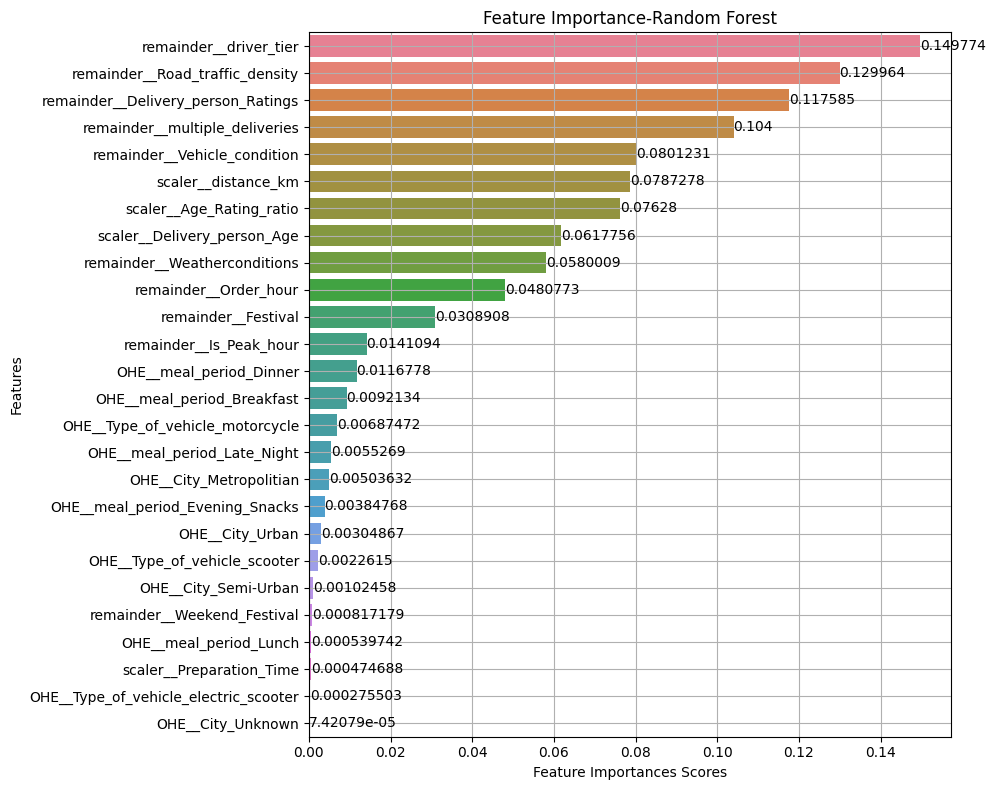

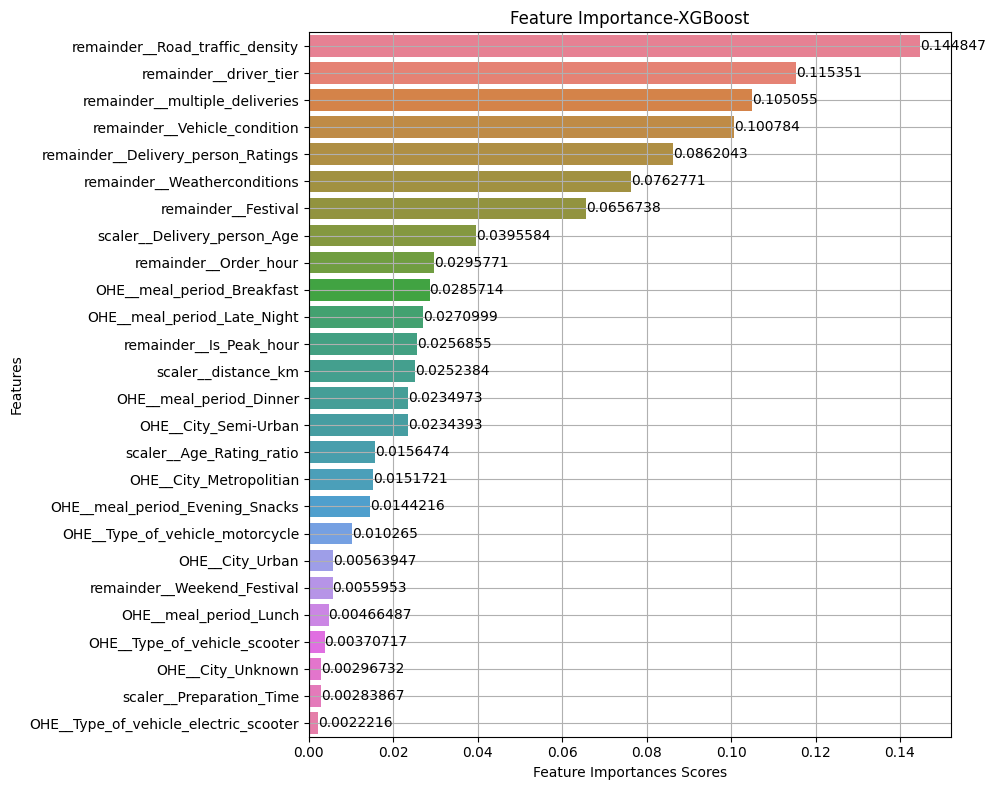

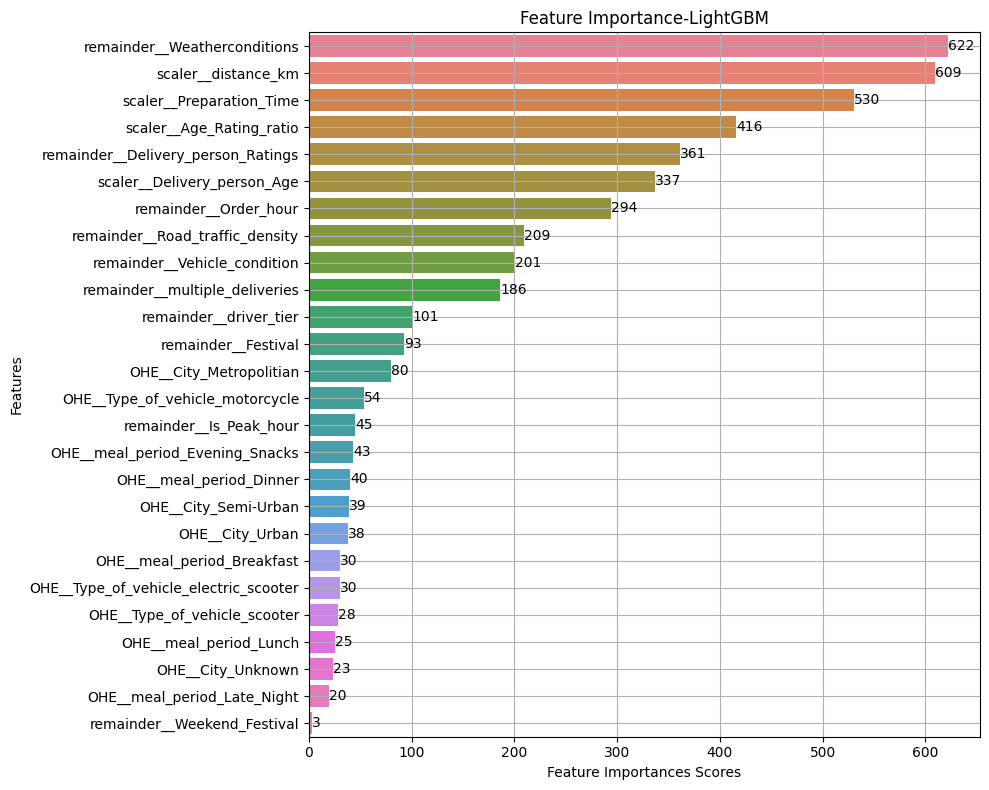

In [ ]:
for m_name,Models in models.items() :
  if m_name in ['Random Forest','XGBoost','LightGBM'] :
    feature_importances = models[m_name].feature_importances_
    feature_names = X_train_final.columns
    importance_df = pd.DataFrame({
      'feature' : feature_names,
      'importance' : feature_importances
    }).sort_values('importance',ascending=False)
    plt.figure(figsize=(10,8))
    plot = sns.barplot(data=importance_df,y='feature',x='importance',hue='feature')
    for i in plot.containers :
      plot.bar_label(i)
    plt.grid()
    plt.title(f"Feature Importance-{m_name}")
    plt.xlabel("Feature Importances Scores")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

### **14. Hyperparameter Tuning Best performing models**

In [ ]:
xgb_param_grid = {
    'n_estimators': [200,400,500,600,700],
    'max_depth': [4,5,6],
    'learning_rate': [0.01, 0.03, 0.05, 0.06],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [5,7,10,15],
    'gamma': [0.1, 0.2, 0.3,0.5],
    'reg_alpha': [0.1,0.5,1,2],
    'reg_lambda': [1, 1.5, 2,3,5]
}

# --- Random Forest ---
rf_param_grid = {
    'n_estimators': [150,200,300, 400, 600],
    'max_depth': [7, 8, 10, 12],
    'min_samples_split': [2, 5, 10,15],
    'min_samples_leaf': [1,5,10,20,30,40],
    'max_features': ['sqrt', 'log2', 0.6, 0.8],
    'bootstrap': [True]
}

# --- LightGBM ---
lgbm_param_grid = {
    'n_estimators': [200, 300, 400,500, 600],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5,7, 8,10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.85],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.85],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 1.5, 2]
}

best_models = {
    'xgb': XGBRegressor(random_state=42,n_jobs=1, tree_method='hist'),
    'rf': RandomForestRegressor(random_state=42),
    'lgbm': LGBMRegressor(random_state=42)
}

In [ ]:
RFsearch = RandomizedSearchCV(estimator=best_models['rf'],param_distributions=rf_param_grid,cv=3,n_jobs=-1,scoring='neg_root_mean_squared_error',n_iter=50,random_state=42)
RFsearch.fit(X_train_final,Y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [7, 8, 10, 12],
                                        'max_features': ['sqrt', 'log2', 0.6,
                                                         0.8],
                                        'min_samples_leaf': [1, 5, 10, 20, 30,
                                                             40],
                                        'min_samples_split': [2, 5, 10, 15],
                                        'n_estimators': [150, 200, 300, 400,
                                                         600]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
RFsearch.best_params_

{'n_estimators': 400,
 'min_samples_split': 5,
 'min_samples_leaf': 5,
 'max_features': 0.6,
 'max_depth': 12,
 'bootstrap': True}

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor',processor),
    ('rf_regressor',RandomForestRegressor(n_estimators=400,min_samples_split=5,min_samples_leaf=5,max_features=0.6,max_depth=12,bootstrap=True,random_state=42))
])

rf_pipeline.fit(X_train,Y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Delivery_person_Age',
                                                   'distance_km',
                                                   'Preparation_Time',
                                                   'Age_Rating_ratio']),
                                                 ('OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Type_of_vehicle', 'City',
                                                   'meal_period'])])),
                ('rf_regressor',
                 RandomForestRegressor(max_depth=12, max_features=0.6,
                                       min_samples_leaf=5, min_samples_split=5,
                                       n_estimators=400, random_state=42))])

In [ ]:
rf_predictions = rf_pipeline.predict(X_test)
print(f"Training Score : {rf_pipeline.score(X_train,Y_train)}")
print(f"Testing Score : {rf_pipeline.score(X_test,Y_test)}")
print(f"MSE : {mean_squared_error(Y_test,rf_predictions)}")
print(f"RMSE : {root_mean_squared_error(Y_test,rf_predictions)}")
print(f"MAE : {mean_absolute_error(Y_test,rf_predictions)}")

Training Score : 0.827534331334276
Testing Score : 0.794986015476461
MSE : 17.365976270799212
RMSE : 4.167250444933591
MAE : 3.319598364946742


In [ ]:
XGBsearch = RandomizedSearchCV(estimator=best_models['xgb'],param_distributions=xgb_param_grid,cv=5,n_jobs=-1,scoring='neg_root_mean_squared_error',n_iter=75,random_state=42)
XGBsearch.fit(X_train_final,Y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                   n_iter=75, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8],
                                        'gamma': [0.1, 0.2, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.06],
                                        'max_depth': [4, 5, 6],
                                        'min_child_weight': [5, 7, 10, 15],
                                        'n_estimators': [200, 400, 500, 600,
                                                         700],
                                        'reg_alpha': [0.1, 0.5, 1, 2],
                                        'reg_lambda': [1, 1.5, 2, 3, 5],
                                        'subsample': [0.6, 0.7, 0.8]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
XGBsearch.best_params_

{'subsample': 0.8,
 'reg_lambda': 2,
 'reg_alpha': 1,
 'n_estimators': 500,
 'min_child_weight': 10,
 'max_depth': 6,
 'learning_rate': 0.03,
 'gamma': 0.1,
 'colsample_bytree': 0.8}

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor',processor),
    ('xgb_regressor',XGBRegressor(n_estimators=500,subsample=0.8,reg_lambda=2,reg_alpha=1,min_child_weight=10,max_depth=6,learning_rate=0.03,gamma=0.1,colsample_bytree=0.8,random_state=42))
])

xgb_pipeline.fit(X_train,Y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Delivery_person_Age',
                                                   'distance_km',
                                                   'Preparation_Time',
                                                   'Age_Rating_ratio']),
                                                 ('OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Type_of_vehicle', 'City',
                                                   'meal_period'])])),
                ('xgb_regressor',
                 XGBRegressor(base_score=None, b...
                              feature_types=None, feature_weights=None,
                              gamma=0.1, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None, min_child_weight=10,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=500,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [ ]:
xgb_prediction = xgb_pipeline.predict(X_test)
print(f"Training Score : {xgb_pipeline.score(X_train,Y_train)}")
print(f"Testing Score : {xgb_pipeline.score(X_test,Y_test)}")
print(f"MSE : {mean_squared_error(Y_test,xgb_prediction)}")
print(f"RMSE : {root_mean_squared_error(Y_test,xgb_prediction)}")
print(f"MAE : {mean_absolute_error(Y_test,xgb_prediction)}")

Training Score : 0.8206775831573326
Testing Score : 0.7906931967628721
MSE : 17.72960506465092
RMSE : 4.210653757393372
MAE : 3.328232391490209


In [ ]:
lgbmsearch = RandomizedSearchCV(estimator=best_models['lgbm'],param_distributions=lgbm_param_grid,cv=5,n_jobs=-1,scoring='neg_root_mean_squared_error',n_iter=75,random_state=42)
lgbmsearch.fit(X_train_final,Y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data points in the train set: 35161, number of used features: 26
[LightGBM] [Info] Start training from score 26.491937


RandomizedSearchCV(cv=5, estimator=LGBMRegressor(random_state=42), n_iter=75,
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8,
                                                             0.85],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [-1, 5, 7, 8, 10],
                                        'min_child_samples': [10, 20, 30, 50],
                                        'n_estimators': [200, 300, 400, 500,
                                                         600],
                                        'num_leaves': [15, 31, 63, 127],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [0.5, 1, 1.5, 2],
                                        'subsample': [0.6, 0.7, 0.8, 0.85]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
lgbmsearch.best_params_

{'subsample': 0.85,
 'reg_lambda': 0.5,
 'reg_alpha': 1,
 'num_leaves': 127,
 'n_estimators': 600,
 'min_child_samples': 10,
 'max_depth': 10,
 'learning_rate': 0.01,
 'colsample_bytree': 0.85}

In [ ]:
lgbm_regressor = Pipeline(steps=[
    ('preprocessor',processor),
    ('lgbm_regressor',LGBMRegressor(n_estimators=600,subsample=0.85,reg_lambda=0.5,reg_alpha=1,num_leaves=127,max_depth=10,learning_rate=0.01,min_child_samples=10,colsample_bytree=0.85,random_state=42))
])

lgbm_regressor.fit(X_train,Y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data points in the train set: 35161, number of used features: 26
[LightGBM] [Info] Start training from score 26.491937


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Delivery_person_Age',
                                                   'distance_km',
                                                   'Preparation_Time',
                                                   'Age_Rating_ratio']),
                                                 ('OHE',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Type_of_vehicle', 'City',
                                                   'meal_period'])])),
                ('lgbm_regressor',
                 LGBMRegressor(colsample_bytree=0.85, learning_rate=0.01,
                               max_depth=10, min_child_samples=10,
                               n_estimators=600, num_leaves=127,
                               random_state=42, reg_alpha=1, reg_lambda=0.5,
                               subsample=0.85))])

In [ ]:
lgbm_prediction = lgbm_regressor.predict(X_test)
print(f"Training Score : {lgbm_regressor.score(X_train,Y_train)}")
print(f"Testing Score : {lgbm_regressor.score(X_test,Y_test)}")
print(f"MSE : {mean_squared_error(Y_test,lgbm_prediction)}")
print(f"RMSE : {root_mean_squared_error(Y_test,lgbm_prediction)}")
print(f"MAE : {mean_absolute_error(Y_test,lgbm_prediction)}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training Score : 0.8340115248075226


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Testing Score : 0.8009173130696321
MSE : 16.863557991883074
RMSE : 4.106526268256794
MAE : 3.2666047155137234


### **Feature Importance of Tuned models**

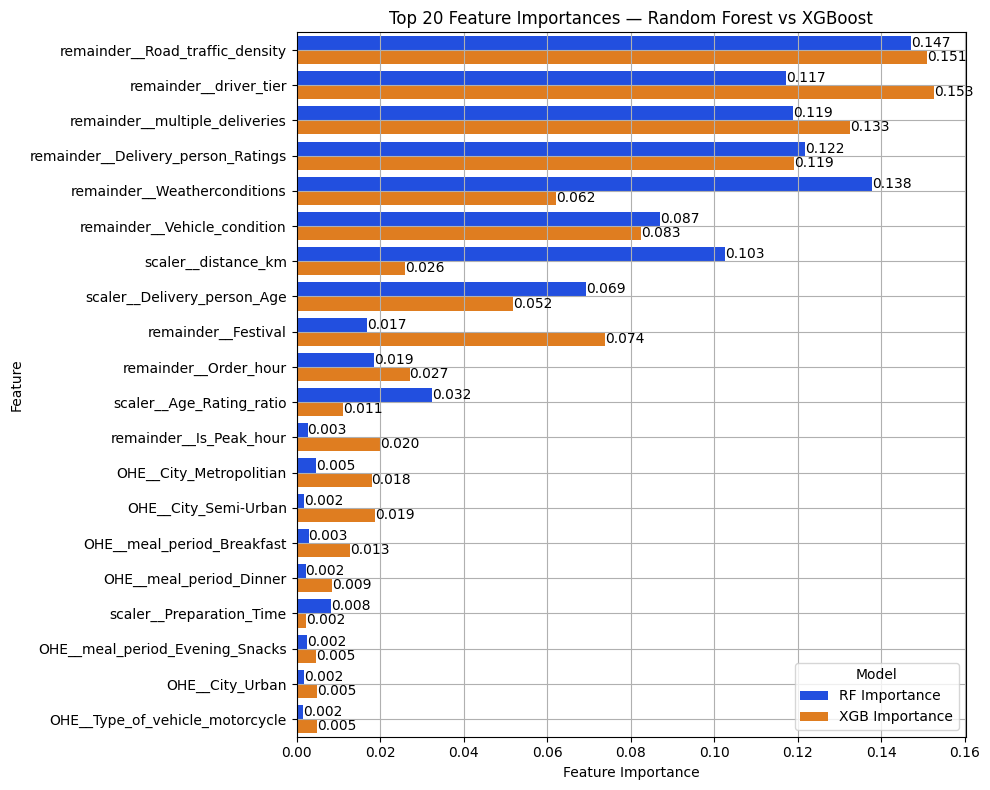

In [ ]:
# ---------------------------------------------------------
# 1. Extract & prepare feature importances
# ---------------------------------------------------------
feature_names = rf_pipeline[:-1].get_feature_names_out()

# NOTE: If using a scikit-learn Pipeline, you must access the model step.
# Replace 'classifier' with the actual name of the model step in your pipeline.
rf_importances = rf_pipeline.named_steps['rf_regressor'].feature_importances_
xgb_importances = xgb_pipeline.named_steps['xgb_regressor'].feature_importances_

# Create separate DataFrames for each model
df_rf = pd.DataFrame({
    'Feature': feature_names,
    'Feature Importance': rf_importances,
    'Model': 'RF Importance'
})

df_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Feature Importance': xgb_importances,
    'Model': 'XGB Importance'
})

# Combine into long format (required for Seaborn grouping)
df_all = pd.concat([df_rf, df_xgb], ignore_index=True)

# ---------------------------------------------------------
# 2. Filter for Top 20 features (sorted by average importance)
# ---------------------------------------------------------
top_20_order = (
    df_all.groupby('Feature')['Feature Importance']
    .mean()
    .nlargest(20)
    .index
)

# This correctly isolates the top 20 without needing to use .melt()
df_top20 = df_all[df_all['Feature'].isin(top_20_order)]

# ---------------------------------------------------------
# 3. Create the Seaborn Barplot
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

plot = sns.barplot(
    data=df_top20,
    x='Feature Importance',
    y='Feature',
    hue='Model',
    order=top_20_order,                   # Keeps top-to-bottom order
    palette='bright'
)

for i in plot.containers :
  plot.bar_label(i,fmt='%.3f')
# ---------------------------------------------------------
# 4. Styling matching the image
# ---------------------------------------------------------
plt.grid()
plt.title('Top 20 Feature Importances — Random Forest vs XGBoost')
plt.xlabel('Feature Importance', fontsize=10)
plt.ylabel('Feature', fontsize=10)

# Position legend in lower right corner
plt.legend(title='Model')

plt.tight_layout()
plt.show()

### **Using Neural Network(MCP)**

In [ ]:
ann = Sequential()
ann.add(Dense(256,input_dim=X_train_final.shape[1],activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(128,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(64,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(32,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(1,activation='linear'))

ann.compile(optimizer='adam',loss='mse',metrics=['mae'])
ann.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,121 (207.50 KB)

 Trainable params: 52,161 (203.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
ANN = ann.fit(X_train_final,Y_train,batch_size=200,epochs=20,validation_data=[X_test_final,Y_test],callbacks=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True))

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 688.5219 - mae: 25.4372 - val_loss: 594.5136 - val_mae: 23.4898
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 467.0961 - mae: 20.8169 - val_loss: 302.9601 - val_mae: 16.5610
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 205.2957 - mae: 13.1724 - val_loss: 127.9198 - val_mae: 10.0372
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 62.2783 - mae: 6.3679 - val_loss: 30.3679 - val_mae: 4.1807
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 27.4933 - mae: 3.8984 - val_loss: 26.6716 - val_mae: 3.7975
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 23.7030 - mae: 3.6130 - val_loss: 24.8517 - val_mae: 3.7010
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 22.9176 - mae: 3.5606 - val_loss: 23.0864 - val_mae: 3.5861
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 22.7442 - mae: 3.5521 - val_loss: 23.0775 - val_mae: 3.5492
Epoch 9/20
176/176 ━━━━━━━

In [ ]:
ann.evaluate(X_test_final,Y_test)

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 21.7535 - mae: 3.4710


[21.75347328186035, 3.4710354804992676]

In [ ]:
y_pred = ann.predict(X_test_final).flatten()

# Calculate performance metrics
final_r2 = r2_score(Y_test, y_pred)
final_mse = mean_squared_error(Y_test, y_pred)

print("\n=== ANN Performance Evaluation ===")
print(f"Final Test R2 Score: {final_r2:.2%}")
print(f"Final Test MSE:      {final_mse:.2f}")


123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

=== ANN Performance Evaluation ===
Final Test R2 Score: 77.11%
Final Test MSE:      19.39


### **Cross-Validation to validate model**

In [ ]:
cv = KFold(n_splits=5,shuffle=True,random_state=42)
scoring = {'r2' : 'r2' , 'mse' : 'neg_mean_squared_error', 'mae' : 'neg_mean_absolute_error' , 'rmse' : 'neg_root_mean_squared_error'}

In [ ]:
for cv_name , pipe in [("Random Forest",rf_pipeline),("XGBoost",xgb_pipeline)] :

  cv_results = cross_validate(pipe,X_train,Y_train,cv=cv,scoring=scoring,return_train_score=True,n_jobs=-1)

  print(cv_name)
  print(f"Train R2 Score : {cv_results['train_r2'].mean()}")
  print(f"Test R2 Score : {cv_results['test_r2'].mean()}")
  print(f"MSE : {-cv_results['test_mse'].mean()}")
  print(f"MAE : {-cv_results['test_mae'].mean()}")
  print(f"RMSE : {-cv_results['test_rmse'].mean()}")
  print("\n")

Random Forest
Train R2 Score : 0.8305731188427877
Test R2 Score : 0.7945821951131833
MSE : 17.92560493001256
MAE : 3.3786775825890936
RMSE : 4.233823264759955


XGBoost
Train R2 Score : 0.8246134488652865
Test R2 Score : 0.7929239186981963
MSE : 18.06903693524155
MAE : 3.3869434357157227
RMSE : 4.250741440078936




In [ ]:
cv_results

{'fit_time': array([3.93725681, 3.83058095, 5.51604152, 5.67909217, 2.31518197]),
 'score_time': array([0.18938088, 0.18849468, 0.19035578, 0.18865895, 0.08929944]),
 'test_r2': array([0.78847079, 0.79406596, 0.79493492, 0.78765627, 0.79949164]),
 'train_r2': array([0.82568204, 0.82445866, 0.82416058, 0.82532027, 0.8234457 ]),
 'test_mse': array([-17.96050251, -17.98038306, -18.13900381, -18.29424993,
        -17.97104537]),
 'train_mse': array([-15.32174668, -15.32364664, -15.29973724, -15.29934025,
        -15.30878406]),
 'test_mae': array([-3.37226894, -3.38269178, -3.38152883, -3.41081359, -3.38741404]),
 'train_mae': array([-3.11721924, -3.1128669 , -3.10877411, -3.10716162, -3.10780796]),
 'test_rmse': array([-4.23798331, -4.24032818, -4.25899094, -4.2771778 , -4.23922698]),
 'train_rmse': array([-3.91430028, -3.91454297, -3.91148786, -3.91143711, -3.91264413])}

### **Saving the Best Model Pipeline using both pickle and joblib : RandomForest**

In [ ]:
import pickle
with open("RF_Pipeline.pkl","wb") as file :
  pickle.dump(rf_pipeline,file)

In [ ]:
import joblib
joblib.dump(rf_pipeline,'rf_pipeline.joblib',compress=3)

['rf_pipeline.joblib']

### **Learning Curves for Random Forest : Best Performing Model**

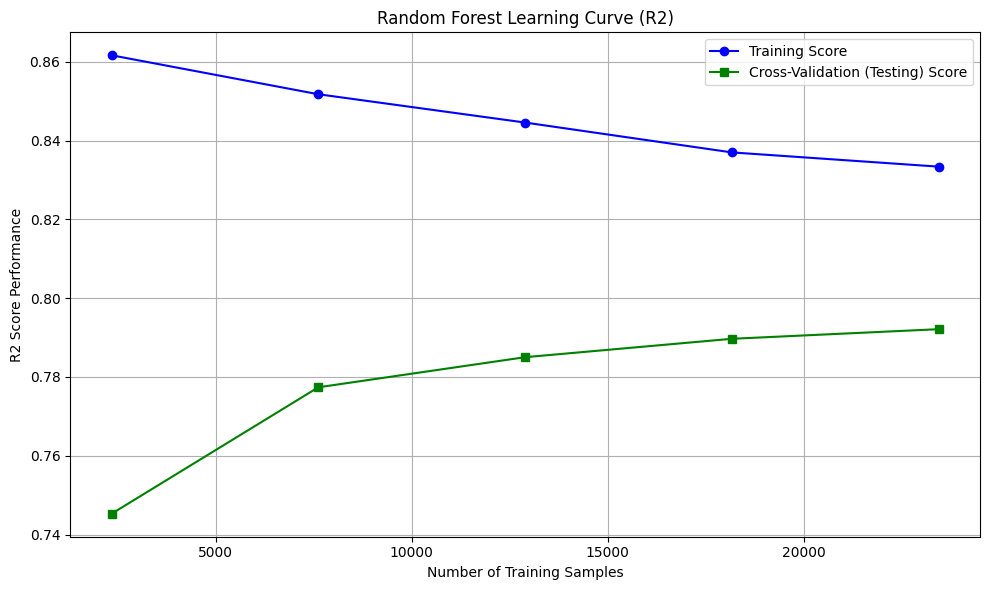

In [ ]:
# Calculate learning curve data (using negative MSE as the scoring metric)
train_sizes, train_scores, test_scores = learning_curve(
    rf_pipeline,
    X_train,
    Y_train,
    cv=3,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Calculate mean
train_mean = np.mean(train_scores,axis=1)
test_mean = np.mean(test_scores,axis=1)
# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o', color='blue')
plt.plot(train_sizes, test_mean, label='Cross-Validation (Testing) Score', marker='s', color='green')

plt.title('Random Forest Learning Curve (R2)')
plt.xlabel('Number of Training Samples')
plt.ylabel('R2 Score Performance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

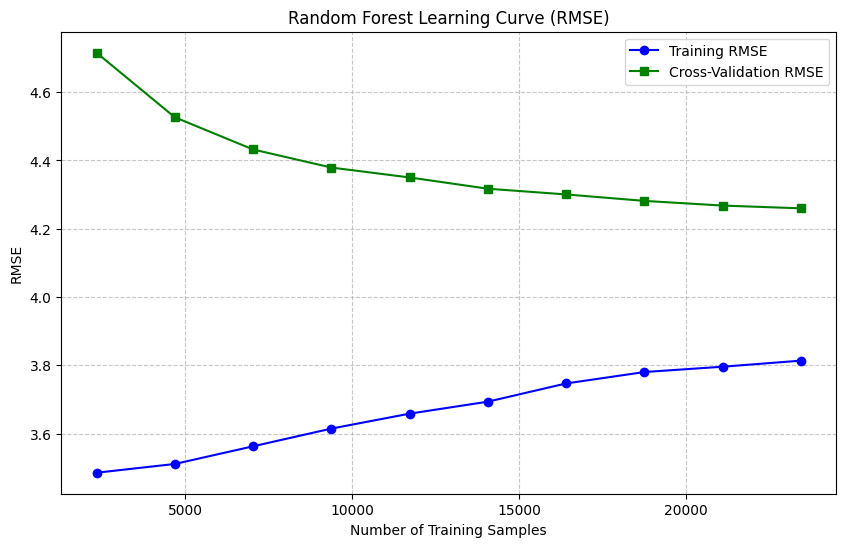

In [ ]:
# Calculate learning curve data using RMSE directly
train_sizes, train_scores, test_scores = learning_curve(
    rf_pipeline,
    X_train,
    Y_train,
    cv=3,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Since the scoring outputs negative RMSE, we only need to flip the sign
train_rmse = -train_scores.mean(axis=1)
test_rmse = -test_scores.mean(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse, label='Training RMSE', marker='o', color='blue')
plt.plot(train_sizes, test_rmse, label='Cross-Validation RMSE', marker='s', color='green')

plt.title('Random Forest Learning Curve (RMSE)')
plt.xlabel('Number of Training Samples')
plt.ylabel('RMSE')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# **📌Conclusion**

**This project demonstrates how effective data preprocessing, feature engineering, model validation, and hyperparameter optimization can significantly enhance delivery-time prediction. The resulting model provides a data-driven approach to estimating ETAs, which can help logistics businesses improve route planning, delivery efficiency, customer satisfaction, and operational decision-making.**


